# PROYECTO FINAL — DATA SCIENCE I "Estudio de integridad financiera en datasets comerciales"

## Auditoría y reconstrucción de un dataset de retail con inconsistencias estructurales

**Autor:** Amilcar Fernández  
**Curso:** Data Science I  
**Fecha:** [19/03/2026]

---

### Abstract
Este proyecto analiza un dataset sintético de ventas minoristas que presenta inconsistencias estructurales, errores matemáticos y valores faltantes, con el objetivo de demostrar la importancia de la auditoría de datos antes de realizar análisis de negocio. A diferencia de un enfoque tradicional centrado únicamente en visualizaciones comerciales, este trabajo prioriza la evaluación de la integridad del conjunto de datos como condición previa a cualquier interpretación estratégica.

Durante la exploración inicial se detectaron columnas financieras internamente inconsistentes, incluyendo subtotales, descuentos y totales finales que no respetaban relaciones aritméticas básicas entre precio, cantidad y costos de envío. También se identificaron valores faltantes en variables críticas, los cuales fueron tratados mediante reconstrucción determinista o imputación contextual, evitando el uso de promedios estadísticos para no introducir información artificial.

Se desarrolló una metodología comparativa que enfrenta análisis sobre datos crudos contra análisis realizados tras la reconstrucción matemática de las métricas financieras. A través de histogramas, gráficos de barras y diagramas de dispersión, se demostró que las inconsistencias no alteraban drásticamente la forma macro del negocio, pero sí producían distorsiones contables significativas que podrían afectar rankings de desempeño, rentabilidad por categoría y decisiones comerciales sensibles.

Adicionalmente, se reconstruyó el margen de beneficio real por unidad y total, revelando discrepancias acumuladas capaces de generar interpretaciones financieras erróneas en escenarios empresariales reales. El proyecto evidencia que errores aparentemente menores en datasets transaccionales pueden escalar hasta conclusiones estratégicas incorrectas si no se implementan procesos de auditoría rigurosos.

Este trabajo demuestra que la calidad de los datos no es una etapa opcional sino un requisito fundamental para el análisis confiable. Más que un ejercicio de visualización, el proyecto funciona como un estudio práctico sobre integridad de datos, fiabilidad analítica y el impacto directo que tiene la corrección de errores en la toma de decisiones de negocio.

--- 

## Objetivo del proyecto

Este proyecto analiza un dataset de ventas minoristas que presenta inconsistencias estructurales y errores matemáticos en sus totales.  
El objetivo no es únicamente explorar el negocio, sino demostrar la importancia de la auditoría de datos antes de cualquier análisis de toma de decisiones.

Se parte de un conjunto de datos con valores incompletos, cálculos incorrectos y formatos inconsistentes, y se aplica un proceso de:

- Auditoría de calidad de datos  
- Reconstrucción determinística de valores faltantes  
- Corrección matemática de totales  
- Comparación entre datos crudos vs datos corregidos  
- Análisis exploratorio del impacto de los errores

Este enfoque simula un escenario real donde decisiones empresariales pueden basarse en información defectuosa.

---

## Introducción

En análisis de datos reales, los errores no siempre son evidentes.  
Muchas veces los datasets parecen coherentes a simple vista, pero esconden inconsistencias que pueden alterar decisiones estratégicas.

Este proyecto utiliza un dataset sintético de retail que contiene:

- Totales mal calculados
- descuentos inconsistentes
- márgenes de ganancia incorrectos
- valores faltantes
- fechas mal formateadas

Aunque las visualizaciones iniciales no muestran errores groseros a nivel macro, un análisis profundo revela diferencias significativas que podrían:

- alterar rankings de empleados
- distorsionar categorías más rentables
- afectar incentivos financieros
- generar decisiones comerciales equivocadas

El proyecto demuestra que:

> Un análisis sin auditoría es estadísticamente elegante pero empresarialmente peligroso.
---

## Preguntas e hipótesis del proyecto

1. ¿Los totales del dataset reflejan ventas reales?
   → Hipótesis: existen errores matemáticos significativos.

2. ¿Las inconsistencias alteran rankings de empleados?
   → Hipótesis: sí, el rendimiento aparente cambia tras la corrección.

3. ¿Las categorías más rentables se mantienen tras la auditoría?
   → Hipótesis: algunas posiciones se alteran.

4. ¿La distribución geográfica del negocio es estable?
   → Hipótesis: el patrón general se mantiene, pero los valores cambian.

5. ¿Los descuentos impactan correctamente en los ingresos?
   → Hipótesis: el cálculo defectuoso distorsiona la rentabilidad.

---
El conjunto de datos proporcionado es un conjunto de datos sintético extraídos de Kaggle **(https://www.kaggle.com/datasets/rajneesh231/retail-insights-a-comprehensive-sales-dataset)** que representa la información de ventas de una empresa, con 5000 entradas y 24 columnas. Los datos abarcan diversos aspectos de las transacciones de venta, incluyendo detalles de pedidos, información del cliente, detalles del producto, precios e información de envío. A continuación, un desglose detallado de cada columna:

## Diccionario de Datos 


| COLUMN | COLUMNA | DESCRIPCIÓN |
|--------|---------|-------------|
| Order No | Número de Orden | Identificador único para cada pedido |
| Order Date | Fecha del Pedido | Fecha en la que se realizó el pedido |
| Customer Name | Nombre del Cliente | Nombre del cliente que realizó el pedido |
| Address | Dirección | Dirección del cliente |
| City | Ciudad | Ciudad donde reside el cliente |
| State | Estado | Estado donde reside el cliente |
| Customer Type | Tipo de Cliente | Minorista, mayorista, corporativo, etc. |
| Account Manager | Gestor de Cuenta | Empleado responsable del pedido |
| Order Priority | Prioridad del Pedido | Nivel de prioridad del pedido |
| Product Name | Nombre del Producto | Producto vendido |
| Product Category | Categoría del Producto | Categoría a la que pertenece el producto |
| Product Container | Envase del Producto | Tipo de envase |
| Ship Mode | Modo de Envío | Método de envío utilizado |
| Ship Date | Fecha de Envío | Fecha de envío del pedido |
| Cost Price | Precio de Costo | Costo del producto |
| Retail Price | Precio de Venta | Precio de venta al cliente |
| Profit Margin | Margen de Beneficio | Diferencia entre costo y venta |
| Order Quantity | Cantidad de Pedido | Unidades compradas |
| Sub Total | Subtotal | Total antes de descuentos |
| Discount % | Descuento % | Porcentaje de descuento aplicado |
| Discount USD | Descuento USD | Monto monetario del descuento |
| Order Total | Total del Pedido | Total tras descuentos |
| Shipping Cost | Costo de Envío | Costo logístico |
| Total | Total Final | Total final con envío incluido |

## Índice del análisis

1. [Carga de librerías y configuración del entorno](#Carga-de-librerías-y-configuración-del-entorno)  
2. [Carga y exploración inicial del dataset](#Carga-y-exploración-inicial-del-dataset)  
3. [Auditoría de calidad de datos](#Auditoría-de-calidad-de-datos)  
4. [Reconstrucción determinística de variables financieras](#Reconstrucción-determinística-de-variables-financieras)  
5. [Comparación mediante visualizaciones entre datos originales y corregidos](#Comparación-mediante-visualizaciones-entre-datos-originales-y-corregidos)  
6. [Resumen estadístico](#Resumen-estadístico)
7. [Limpieza y refinamiento del dataframe](#Limpieza-y-refinamiento-del-dataframe) 
8. [Segmentación de clientes mediante clustering](#Segmentación-de-clientes-mediante-clustering)  
9. [Segmentación de productos mediante clustering](#Segmentación-de-productos-mediante-clustering)  
10. [Análisis cruzado entre clusters](#Análisis-cruzado-entre-clusters)  
11. [Entrenamiento del modelo de clasificación](#Entrenamiento-del-modelo-de-clasificación)  
12. [Evaluación del modelo](#Evaluación-del-modelo)  
13. [Visualización del árbol de decisión](#Visualización-del-árbol-de-decisión)  
14. [Conclusiones del análisis](#Conclusiones-del-análisis)  
15. [Metodología de trabajo y uso de herramientas de IA](#Metodología-de-trabajo-y-uso-de-herramientas-de-IA)  
16. [Alcance y limitaciones del análisis](#Alcance-y-limitaciones-del-análisis)

## Carga de librerías y configuración del entorno 

In [420]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import os
os.environ["OMP_NUM_THREADS"] = "2"
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.tree import plot_tree

## Carga y exploración inicial del dataset

In [421]:
ruta = r"C:\Users\amilc\OneDrive\DATA SCIENCE I\Documentación Complementaria\Proyecto Final\retail-data-quality-proyect\data\raw\Retail_Insights_A_Comprehensive_Sales_Dataset.csv"

df_raw = pd.read_csv(ruta)

In [422]:
df_raw.columns

Index(['Order No', 'Order Date', 'Customer Name', 'Address', 'City', 'State',
       'Customer Type', 'Account Manager', 'Order Priority', 'Product Name',
       'Product Category', 'Product Container', 'Ship Mode', 'Ship Date',
       'Cost Price', 'Retail Price', 'Profit Margin', 'Order Quantity',
       'Sub Total', 'Discount %', 'Discount $', 'Order Total', 'Shipping Cost',
       'Total'],
      dtype='object')

In [423]:
df_raw.head()

,Order No,Order Date,Customer Name,Address,City,State,Customer Type,Account Manager,Order Priority,Product Name,...,Cost Price,Retail Price,Profit Margin,Order Quantity,Sub Total,Discount %,Discount $,Order Total,Shipping Cost,Total
0,4293-1,02-09-2014,Vivek Sundaresam,"152 Bunnerong Road,Eastgardens",Sydney,NSW,Small Business,Tina Carlton,Critical,UGen Ultra Professional Cordless Optical Suite,...,$156.50,$300.97,$144.47,23.0,"$4,533.52",2%,$194.83,"$4,757.22",$7.18,"$4,291.55"
1,5001-1,24-10-2015,Shahid Hopkins,"438 Victoria Avenue,Chatswood",Sydney,NSW,Corporate,Natasha Song,Medium,Bagged Rubber Bands,...,$0.24,$1.26,$1.02,8.0,$45.20,3%,$0.00,$45.90,$0.70,$46.91
2,5004-1,13-03-2014,Dennis Pardue,"412 Brunswick St,Fitzroy",Melbourne,VIC,Consumer,Connor Betts,Not Specified,TechSavi Cordless Navigator Duo,...,$42.11,$80.98,$38.87,45.0,$873.32,4%,$72.23,$837.57,$7.18,$82.58
3,5009-1,18-02-2013,Sean Wendt,"145 Ramsay St,Haberfield",Sydney,NSW,Small Business,Phoebe Gour,Critical,Artisan Printable Repositionable Plastic Tabs,...,$5.33,$8.60,$3.27,16.0,$73.52,1%,$4.35,$740.67,$6.19,$730.92
4,5010-1,13-09-2014,Christina Vanderzanden,"188 Pitt Street,Sydney",Sydney,NSW,Small Business,Tina Carlton,Not Specified,Pizazz Drawing Pencil Set,...,$1.53,$2.78,$1.25,49.0,$138.46,7%,$5.95,$123.77,$1.34,$125.97


In [424]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Order No           5000 non-null   object 
 1   Order Date         5000 non-null   object 
 2   Customer Name      5000 non-null   object 
 3   Address            4999 non-null   object 
 4   City               5000 non-null   object 
 5   State              5000 non-null   object 
 6   Customer Type      5000 non-null   object 
 7   Account Manager    5000 non-null   object 
 8   Order Priority     5000 non-null   object 
 9   Product Name       5000 non-null   object 
 10  Product Category   5000 non-null   object 
 11  Product Container  5000 non-null   object 
 12  Ship Mode          5000 non-null   object 
 13  Ship Date          5000 non-null   object 
 14  Cost Price         5000 non-null   object 
 15  Retail Price       5000 non-null   object 
 16  Profit Margin      5000 

In [425]:
df_raw['Order Date'].unique()[:15]

array(['02-09-2014', '24-10-2015', '13-03-2014', '18-02-2013',
       '13-09-2014', '24-11-2013', '07-09-2014', '28-01-2015',
       '08-06-2014', '02-10-2014', '01-04-2014', '11-02-2013',
       '29-12-2013', '18-11-2013', '13-02-2013'], dtype=object)

In [426]:
df_raw['Order Date'] = pd.to_datetime(
    df_raw['Order Date'],
    format='%d-%m-%Y'
)

In [427]:
df_raw['Order Date'].head()

0   2014-09-02
1   2015-10-24
2   2014-03-13
3   2013-02-18
4   2014-09-13
Name: Order Date, dtype: datetime64[ns]

In [428]:
pd.to_datetime(df_raw['Order Date'].head(5), format='%d-%m-%Y')

0   2014-09-02
1   2015-10-24
2   2014-03-13
3   2013-02-18
4   2014-09-13
Name: Order Date, dtype: datetime64[ns]

In [429]:
df = df_raw.copy()

## Auditoría de calidad de datos

### Creación de listas de columnas con valores monetarios, porcentuales y temporales
Conversión del tipo de dato object a float y a datetime64

In [430]:
money_cols = ['Cost Price','Retail Price','Profit Margin','Sub Total',
              'Discount $','Order Total','Shipping Cost','Total']

for c in money_cols:
    df[c] = (df[c].astype(str)
                .str.replace('$','', regex=False)
                .str.replace(',','', regex=False)
                .astype(float))

In [431]:
pct_cols = ['Discount %']

for c in pct_cols:
    df[c] = (df[c].astype(str)
                .str.replace('%','', regex=False)
                .astype(float) / 100)

In [432]:
date_cols = ['Order Date', 'Ship Date']

for c in date_cols:
    df[c] = pd.to_datetime(df[c], format='%d-%m-%Y', errors='coerce')

In [433]:
df.dtypes

Order No                     object
Order Date           datetime64[ns]
Customer Name                object
Address                      object
City                         object
State                        object
Customer Type                object
Account Manager              object
Order Priority               object
Product Name                 object
Product Category             object
Product Container            object
Ship Mode                    object
Ship Date            datetime64[ns]
Cost Price                  float64
Retail Price                float64
Profit Margin               float64
Order Quantity              float64
Sub Total                   float64
Discount %                  float64
Discount $                  float64
Order Total                 float64
Shipping Cost               float64
Total                       float64
dtype: object

In [434]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order No           5000 non-null   object        
 1   Order Date         5000 non-null   datetime64[ns]
 2   Customer Name      5000 non-null   object        
 3   Address            4999 non-null   object        
 4   City               5000 non-null   object        
 5   State              5000 non-null   object        
 6   Customer Type      5000 non-null   object        
 7   Account Manager    5000 non-null   object        
 8   Order Priority     5000 non-null   object        
 9   Product Name       5000 non-null   object        
 10  Product Category   5000 non-null   object        
 11  Product Container  5000 non-null   object        
 12  Ship Mode          5000 non-null   object        
 13  Ship Date          5000 non-null   datetime64[ns]
 14  Cost Pri

In [435]:
df.head()

,Order No,Order Date,Customer Name,Address,City,State,Customer Type,Account Manager,Order Priority,Product Name,...,Cost Price,Retail Price,Profit Margin,Order Quantity,Sub Total,Discount %,Discount $,Order Total,Shipping Cost,Total
0,4293-1,2014-09-02,Vivek Sundaresam,"152 Bunnerong Road,Eastgardens",Sydney,NSW,Small Business,Tina Carlton,Critical,UGen Ultra Professional Cordless Optical Suite,...,156.50,300.97,144.47,23.0,4533.52,0.02,194.83,4757.22,7.18,4291.55
1,5001-1,2015-10-24,Shahid Hopkins,"438 Victoria Avenue,Chatswood",Sydney,NSW,Corporate,Natasha Song,Medium,Bagged Rubber Bands,...,0.24,1.26,1.02,8.0,45.20,0.03,0.00,45.90,0.70,46.91
2,5004-1,2014-03-13,Dennis Pardue,"412 Brunswick St,Fitzroy",Melbourne,VIC,Consumer,Connor Betts,Not Specified,TechSavi Cordless Navigator Duo,...,42.11,80.98,38.87,45.0,873.32,0.04,72.23,837.57,7.18,82.58
3,5009-1,2013-02-18,Sean Wendt,"145 Ramsay St,Haberfield",Sydney,NSW,Small Business,Phoebe Gour,Critical,Artisan Printable Repositionable Plastic Tabs,...,5.33,8.60,3.27,16.0,73.52,0.01,4.35,740.67,6.19,730.92
4,5010-1,2014-09-13,Christina Vanderzanden,"188 Pitt Street,Sydney",Sydney,NSW,Small Business,Tina Carlton,Not Specified,Pizazz Drawing Pencil Set,...,1.53,2.78,1.25,49.0,138.46,0.07,5.95,123.77,1.34,125.97


In [436]:
df.isna().sum()

Order No             0
Order Date           0
Customer Name        0
Address              1
City                 0
State                0
Customer Type        0
Account Manager      0
Order Priority       0
Product Name         0
Product Category     0
Product Container    0
Ship Mode            0
Ship Date            0
Cost Price           0
Retail Price         0
Profit Margin        0
Order Quantity       1
Sub Total            0
Discount %           0
Discount $           0
Order Total          0
Shipping Cost        0
Total                0
dtype: int64

### Detección de datos faltantes 
#### Columna ['Address'] presenta un dato faltante clasificado de riesgo A (riesgo bajo).
#### Columna ['Order Quantity'] presenta un dato faltante clasificado de riesgo C (riesgo alto).

In [437]:
df.isna().sum()[df.isna().sum() > 0]

Address           1
Order Quantity    1
dtype: int64

In [438]:
df[df.isna().any(axis=1)]

,Order No,Order Date,Customer Name,Address,City,State,Customer Type,Account Manager,Order Priority,Product Name,...,Cost Price,Retail Price,Profit Margin,Order Quantity,Sub Total,Discount %,Discount $,Order Total,Shipping Cost,Total
1411,5428-1,2014-02-25,Jhrip Luxen,"4A Lyons St,Strathfield",Sydney,NSW,Home Office,Tina Carlton,High,Creator Colored Pencils,...,1.57,3.28,1.71,NaN,85.28,0.04,6.82,78.46,0.98,79.44
4354,6384-1,2016-04-27,Patt Bawkins,NaN,Sydney,NSW,Small Business,Tina Carlton,High,HFX LaserJet 3310 Copier,...,377.99,599.99,222.00,47.0,9599.84,0.00,0.00,9599.84,24.49,9624.33


In [439]:
critical_cols = ['Order Quantity', 'Retail Price', 'Total']

In [440]:
df[df[critical_cols].isna().any(axis=1)]

,Order No,Order Date,Customer Name,Address,City,State,Customer Type,Account Manager,Order Priority,Product Name,...,Cost Price,Retail Price,Profit Margin,Order Quantity,Sub Total,Discount %,Discount $,Order Total,Shipping Cost,Total
1411,5428-1,2014-02-25,Jhrip Luxen,"4A Lyons St,Strathfield",Sydney,NSW,Home Office,Tina Carlton,High,Creator Colored Pencils,...,1.57,3.28,1.71,NaN,85.28,0.04,6.82,78.46,0.98,79.44


In [441]:
df.loc[1411]

Order No                              5428-1
Order Date               2014-02-25 00:00:00
Customer Name                    Jhrip Luxen
Address              4A Lyons St,Strathfield
City                                  Sydney
State                                    NSW
Customer Type                    Home Office
Account Manager                 Tina Carlton
Order Priority                          High
Product Name         Creator Colored Pencils
Product Category                   Furniture
Product Container                  Large Box
Ship Mode                        Regular Air
Ship Date                2014-02-26 00:00:00
Cost Price                              1.57
Retail Price                            3.28
Profit Margin                           1.71
Order Quantity                           NaN
Sub Total                              85.28
Discount %                              0.04
Discount $                              6.82
Order Total                            78.46
Shipping C

In [442]:
df.loc[4354]

Order No                               6384-1
Order Date                2016-04-27 00:00:00
Customer Name                    Patt Bawkins
Address                                   NaN
City                                   Sydney
State                                     NSW
Customer Type                  Small Business
Account Manager                  Tina Carlton
Order Priority                           High
Product Name         HFX LaserJet 3310 Copier
Product Category              Office Supplies
Product Container                   Small Box
Ship Mode                         Regular Air
Ship Date                 2016-04-29 00:00:00
Cost Price                             377.99
Retail Price                           599.99
Profit Margin                           222.0
Order Quantity                           47.0
Sub Total                             9599.84
Discount %                                0.0
Discount $                                0.0
Order Total                       

### Imputación de datos faltantes

### Rastreo del cliente, para tratar de imputar la dirección a partir de compras históricas

In [443]:
df_Bawkins = df[df['Customer Name'] == 'Patt Bawkins'] ## Creación de variable del empleado para buscar el historial de compras del mismo.
df_Bawkins

,Order No,Order Date,Customer Name,Address,City,State,Customer Type,Account Manager,Order Priority,Product Name,...,Cost Price,Retail Price,Profit Margin,Order Quantity,Sub Total,Discount %,Discount $,Order Total,Shipping Cost,Total
4354,6384-1,2016-04-27,Patt Bawkins,NaN,Sydney,NSW,Small Business,Tina Carlton,High,HFX LaserJet 3310 Copier,...,377.99,599.99,222.0,47.0,9599.84,0.0,0.0,9599.84,24.49,9624.33


### Debido a la falta de contexto histórico del cliente 'Patt Bawkins' (sólo aparece una vez en el dataset), y considerando el dato faltante de la columna ['Address'] de riesgo bajo ("A"), se decide por renombrarlo 'Unknow' (Desconocido). Evitando así, arrojar datos falsos, ante la imposibilidad de imputación del mismo.

In [444]:
df.loc[df['Address'].isna(), 'Address'] = 'Unknown'

In [445]:
df.loc[4354]

Order No                               6384-1
Order Date                2016-04-27 00:00:00
Customer Name                    Patt Bawkins
Address                               Unknown
City                                   Sydney
State                                     NSW
Customer Type                  Small Business
Account Manager                  Tina Carlton
Order Priority                           High
Product Name         HFX LaserJet 3310 Copier
Product Category              Office Supplies
Product Container                   Small Box
Ship Mode                         Regular Air
Ship Date                 2016-04-29 00:00:00
Cost Price                             377.99
Retail Price                           599.99
Profit Margin                           222.0
Order Quantity                           47.0
Sub Total                             9599.84
Discount %                                0.0
Discount $                                0.0
Order Total                       

In [446]:
df['Address'].isna().sum()


np.int64(0)

### Reconstrucción determinista del dato faltante en ['Order Quantity']


In [447]:
df.loc[1411, 'Order Quantity'] = df.loc[1411, 'Sub Total'] / df.loc[1411, 'Retail Price']

In [448]:
df.loc[1411]

Order No                              5428-1
Order Date               2014-02-25 00:00:00
Customer Name                    Jhrip Luxen
Address              4A Lyons St,Strathfield
City                                  Sydney
State                                    NSW
Customer Type                    Home Office
Account Manager                 Tina Carlton
Order Priority                          High
Product Name         Creator Colored Pencils
Product Category                   Furniture
Product Container                  Large Box
Ship Mode                        Regular Air
Ship Date                2014-02-26 00:00:00
Cost Price                              1.57
Retail Price                            3.28
Profit Margin                           1.71
Order Quantity                          26.0
Sub Total                              85.28
Discount %                              0.04
Discount $                              6.82
Order Total                            78.46
Shipping C

### Se crea la columna ['Quantity_Reconstructured'], para poder verificar a futuro, que datos fueron reconstruidos, respetando la estructura original, y permitiendo además, mayor practicidad y velocidad en futuras auditorías de terceros.

In [449]:
df['Quantity_Reconstructed'] = False
df.loc[1411, 'Quantity_Reconstructed'] = True

In [450]:
df['Quantity_Reconstructed'].value_counts()

Quantity_Reconstructed
False    4999
True        1
Name: count, dtype: int64

In [451]:
df[df['Quantity_Reconstructed'] == True]


,Order No,Order Date,Customer Name,Address,City,State,Customer Type,Account Manager,Order Priority,Product Name,...,Retail Price,Profit Margin,Order Quantity,Sub Total,Discount %,Discount $,Order Total,Shipping Cost,Total,Quantity_Reconstructed
1411,5428-1,2014-02-25,Jhrip Luxen,"4A Lyons St,Strathfield",Sydney,NSW,Home Office,Tina Carlton,High,Creator Colored Pencils,...,3.28,1.71,26.0,85.28,0.04,6.82,78.46,0.98,79.44,True


### Calidad de Datos – Valores Faltantes (Cerrado)

### Todos los valores faltantes fueron analizados individualmente.
#### - Se aplicó reconstrucción determinista donde fue posible (['Order Quantity'] / Cantidad de Pedido).
#### - Se aplicó imputación contextual solo cuando existían patrones históricos fuertes.
#### - No se utilizaron promedios estadísticos para evitar introducir datos artificiales.

#### Esta etapa concluye la fase de tratamiento de valores faltantes.

In [452]:
df.isna().sum()

Order No                  0
Order Date                0
Customer Name             0
Address                   0
City                      0
State                     0
Customer Type             0
Account Manager           0
Order Priority            0
Product Name              0
Product Category          0
Product Container         0
Ship Mode                 0
Ship Date                 0
Cost Price                0
Retail Price              0
Profit Margin             0
Order Quantity            0
Sub Total                 0
Discount %                0
Discount $                0
Order Total               0
Shipping Cost             0
Total                     0
Quantity_Reconstructed    0
dtype: int64

In [453]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Order No                5000 non-null   object        
 1   Order Date              5000 non-null   datetime64[ns]
 2   Customer Name           5000 non-null   object        
 3   Address                 5000 non-null   object        
 4   City                    5000 non-null   object        
 5   State                   5000 non-null   object        
 6   Customer Type           5000 non-null   object        
 7   Account Manager         5000 non-null   object        
 8   Order Priority          5000 non-null   object        
 9   Product Name            5000 non-null   object        
 10  Product Category        5000 non-null   object        
 11  Product Container       5000 non-null   object        
 12  Ship Mode               5000 non-null   object  

## Reconstrucción determinística de variables financieras

### Detección de inconsistencias matemáticas:
Durante la reconstrucción determinística del dato faltante, perteneciente al registro 1411 en la columna ['Order Quantity'], se observó que los valores arrojados en columnas de totales son sospechosos de no ser correctamente calculados. Por lo que se procede a realizar la una auditoría celosa de las columnas de totales (sub total, order total y total) 

In [454]:
df['Order Quantity'].describe()

count    5000.000000
mean       26.483000
std        14.390425
min         1.000000
25%        13.000000
50%        27.000000
75%        39.000000
max        50.000000
Name: Order Quantity, dtype: float64

In [455]:
df[df['Sub Total'] != df['Retail Price'] * df['Order Quantity']]

,Order No,Order Date,Customer Name,Address,City,State,Customer Type,Account Manager,Order Priority,Product Name,...,Retail Price,Profit Margin,Order Quantity,Sub Total,Discount %,Discount $,Order Total,Shipping Cost,Total,Quantity_Reconstructed
0,4293-1,2014-09-02,Vivek Sundaresam,"152 Bunnerong Road,Eastgardens",Sydney,NSW,Small Business,Tina Carlton,Critical,UGen Ultra Professional Cordless Optical Suite,...,300.97,144.47,23.0,4533.52,0.02,194.83,4757.22,7.18,4291.55,False
1,5001-1,2015-10-24,Shahid Hopkins,"438 Victoria Avenue,Chatswood",Sydney,NSW,Corporate,Natasha Song,Medium,Bagged Rubber Bands,...,1.26,1.02,8.0,45.20,0.03,0.00,45.90,0.70,46.91,False
2,5004-1,2014-03-13,Dennis Pardue,"412 Brunswick St,Fitzroy",Melbourne,VIC,Consumer,Connor Betts,Not Specified,TechSavi Cordless Navigator Duo,...,80.98,38.87,45.0,873.32,0.04,72.23,837.57,7.18,82.58,False
3,5009-1,2013-02-18,Sean Wendt,"145 Ramsay St,Haberfield",Sydney,NSW,Small Business,Phoebe Gour,Critical,Artisan Printable Repositionable Plastic Tabs,...,8.60,3.27,16.0,73.52,0.01,4.35,740.67,6.19,730.92,False
4,5010-1,2014-09-13,Christina Vanderzanden,"188 Pitt Street,Sydney",Sydney,NSW,Small Business,Tina Carlton,Not Specified,Pizazz Drawing Pencil Set,...,2.78,1.25,49.0,138.46,0.07,5.95,123.77,1.34,125.97,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,6831-1,2016-11-02,Roland Murray,"438 Victoria Avenue,Chatswood",Sydney,NSW,Corporate,Natasha Song,Critical,Artisan Hi-Liter Smear-Safe Highlighters,...,5.84,2.86,35.0,115.40,0.02,10.81,104.09,0.83,101.22,False
4996,6847-1,2015-12-16,Patrick OBrill,"63 Riley Street,Woolloomooloo",Sydney,NSW,Small Business,Tina Carlton,Not Specified,Smiths Colored Interoffice Envelopes,...,30.98,11.15,49.0,1999.69,0.07,143.91,1947.75,19.51,1052.55,False
4997,6922-1,2016-09-28,Troy Staebel,"1-2/299 Sussex St,Sydney",Sydney,NSW,Consumer,Aanya Zhang,Low,Laser DVD-RAM discs,...,35.41,15.23,19.0,929.40,0.09,27.88,901.52,1.99,921.03,False
4998,6939-1,2016-06-18,Shaun Weien,"Shop 3/144 Wattle St,Ultimo",Sydney,NSW,Corporate,Samantha Chairs,Not Specified,Artisan 479 Labels,...,2.61,1.02,23.0,66.54,0.05,4.46,63.77,0.50,64.27,False


### Se recrea, con cálculos correctos, la columna ['Sub Total'] como ['calc_subtotal']

**['calc_subtotal']:** el mismo refleja el valor que el cliente deberá pagar por cantidad de productos comprados, sin descuento alguno.

**['diff']:** arroja la diferencia existente entre la columna auditada y la columna con los cálculos correctos.

In [456]:
df['calc_subtotal'] = df['Retail Price'] * df['Order Quantity']
df['diff'] = abs(df['Sub Total'] - df['calc_subtotal'])

In [457]:
df['diff'].describe()

count     5000.000000
mean       794.294970
std       2550.214053
min          0.000000
25%         37.477500
50%         97.275000
75%        323.340000
max      26194.020000
Name: diff, dtype: float64

In [458]:
df[df['diff'] > 0.01] ## Se observan a continuación, las filas cuya diferencia entre ['Sub Total'] y ['calc_subtotal'] sea mayor a 10 centavos

,Order No,Order Date,Customer Name,Address,City,State,Customer Type,Account Manager,Order Priority,Product Name,...,Order Quantity,Sub Total,Discount %,Discount $,Order Total,Shipping Cost,Total,Quantity_Reconstructed,calc_subtotal,diff
0,4293-1,2014-09-02,Vivek Sundaresam,"152 Bunnerong Road,Eastgardens",Sydney,NSW,Small Business,Tina Carlton,Critical,UGen Ultra Professional Cordless Optical Suite,...,23.0,4533.52,0.02,194.83,4757.22,7.18,4291.55,False,6922.31,2388.79
1,5001-1,2015-10-24,Shahid Hopkins,"438 Victoria Avenue,Chatswood",Sydney,NSW,Corporate,Natasha Song,Medium,Bagged Rubber Bands,...,8.0,45.20,0.03,0.00,45.90,0.70,46.91,False,10.08,35.12
2,5004-1,2014-03-13,Dennis Pardue,"412 Brunswick St,Fitzroy",Melbourne,VIC,Consumer,Connor Betts,Not Specified,TechSavi Cordless Navigator Duo,...,45.0,873.32,0.04,72.23,837.57,7.18,82.58,False,3644.10,2770.78
3,5009-1,2013-02-18,Sean Wendt,"145 Ramsay St,Haberfield",Sydney,NSW,Small Business,Phoebe Gour,Critical,Artisan Printable Repositionable Plastic Tabs,...,16.0,73.52,0.01,4.35,740.67,6.19,730.92,False,137.60,64.08
4,5010-1,2014-09-13,Christina Vanderzanden,"188 Pitt Street,Sydney",Sydney,NSW,Small Business,Tina Carlton,Not Specified,Pizazz Drawing Pencil Set,...,49.0,138.46,0.07,5.95,123.77,1.34,125.97,False,136.22,2.24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,6831-1,2016-11-02,Roland Murray,"438 Victoria Avenue,Chatswood",Sydney,NSW,Corporate,Natasha Song,Critical,Artisan Hi-Liter Smear-Safe Highlighters,...,35.0,115.40,0.02,10.81,104.09,0.83,101.22,False,204.40,89.00
4996,6847-1,2015-12-16,Patrick OBrill,"63 Riley Street,Woolloomooloo",Sydney,NSW,Small Business,Tina Carlton,Not Specified,Smiths Colored Interoffice Envelopes,...,49.0,1999.69,0.07,143.91,1947.75,19.51,1052.55,False,1518.02,481.67
4997,6922-1,2016-09-28,Troy Staebel,"1-2/299 Sussex St,Sydney",Sydney,NSW,Consumer,Aanya Zhang,Low,Laser DVD-RAM discs,...,19.0,929.40,0.09,27.88,901.52,1.99,921.03,False,672.79,256.61
4998,6939-1,2016-06-18,Shaun Weien,"Shop 3/144 Wattle St,Ultimo",Sydney,NSW,Corporate,Samantha Chairs,Not Specified,Artisan 479 Labels,...,23.0,66.54,0.05,4.46,63.77,0.50,64.27,False,60.03,6.51


### Se crean las columnas calculadas:

#### >['calc_discount']: columna que muestra los valores monetarios de descuento a partir del porcentaje de descuento establecido.
#### >['calc_order_total']: valor total del pedido con los descuentos aplicado.
#### >['calc_total']: valor total a pagar por el cliente considerando, de existir, coste de envío.

#### Con las columnas visualizadas consecutivamente de las columnas auditadas, se puede corroborar la falta de veracidad en los datos crudos aportados por el dataset.

In [459]:
df['calc_discount'] = df['calc_subtotal'] * df['Discount %']

In [460]:
df['calc_order_total'] = df['calc_subtotal'] - df['calc_discount']

In [461]:
df['calc_total'] = df['calc_order_total'] + df['Shipping Cost']

In [462]:
df[['Retail Price','Order Quantity','Sub Total','calc_subtotal','Discount $','calc_discount','Order Total','calc_order_total','Shipping Cost','Total','calc_total']].head(20)

,Retail Price,Order Quantity,Sub Total,calc_subtotal,Discount $,calc_discount,Order Total,calc_order_total,Shipping Cost,Total,calc_total
0,300.97,23.0,4533.52,6922.31,194.83,138.4462,4757.22,6783.8638,7.18,4291.55,6791.0438
1,1.26,8.0,45.20,10.08,0.00,0.3024,45.90,9.7776,0.70,46.91,10.4776
2,80.98,45.0,873.32,3644.10,72.23,145.7640,837.57,3498.3360,7.18,82.58,3505.5160
3,8.60,16.0,73.52,137.60,4.35,1.3760,740.67,136.2240,6.19,730.92,142.4140
4,2.78,49.0,138.46,136.22,5.95,9.5354,123.77,126.6846,1.34,125.97,128.0246
5,7.28,45.0,197.36,327.60,12.98,26.2080,183.58,301.3920,11.15,189.43,312.5420
6,2.62,45.0,65.50,117.90,5.90,4.7160,59.62,113.1840,0.80,60.45,113.9840
7,2.62,34.0,24.92,89.08,2.49,1.7816,22.43,87.2984,0.80,27.43,88.0984
8,6.23,25.0,194.36,155.75,15.93,15.5750,178.12,140.1750,6.97,189.45,147.1450
9,300.97,42.0,1079.62,12640.74,30.83,505.6296,1753.33,12135.1104,7.18,1705.42,12142.2904


In [463]:
(df['Sub Total'] - df['calc_subtotal']).abs().describe()

count     5000.000000
mean       794.294970
std       2550.214053
min          0.000000
25%         37.477500
50%         97.275000
75%        323.340000
max      26194.020000
dtype: float64

In [464]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Order No                5000 non-null   object        
 1   Order Date              5000 non-null   datetime64[ns]
 2   Customer Name           5000 non-null   object        
 3   Address                 5000 non-null   object        
 4   City                    5000 non-null   object        
 5   State                   5000 non-null   object        
 6   Customer Type           5000 non-null   object        
 7   Account Manager         5000 non-null   object        
 8   Order Priority          5000 non-null   object        
 9   Product Name            5000 non-null   object        
 10  Product Category        5000 non-null   object        
 11  Product Container       5000 non-null   object        
 12  Ship Mode               5000 non-null   object  

## Comparación mediante visualizaciones entre datos originales y corregidos

### 1- Histograma

#### Visualizaciones sobre datos crudos

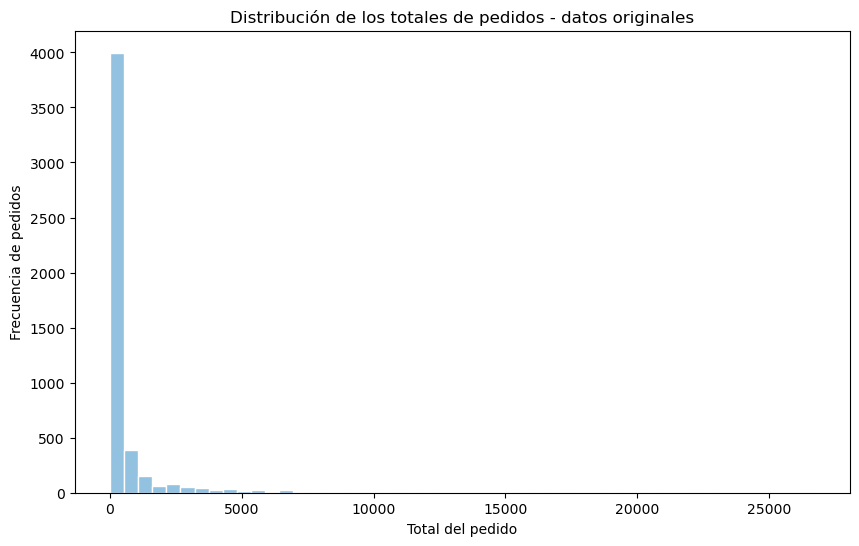

In [465]:

plt.figure(figsize=(10,6))
sns.histplot(df['Total'], 
             bins=50,
             color='#6eaed6',
             edgecolor='white'
)
plt.title('Distribución de los totales de pedidos - datos originales')
plt.xlabel('Total del pedido')
plt.ylabel('Frecuencia de pedidos')
plt.show()


#### Visualizaciones sobre datos corregidos

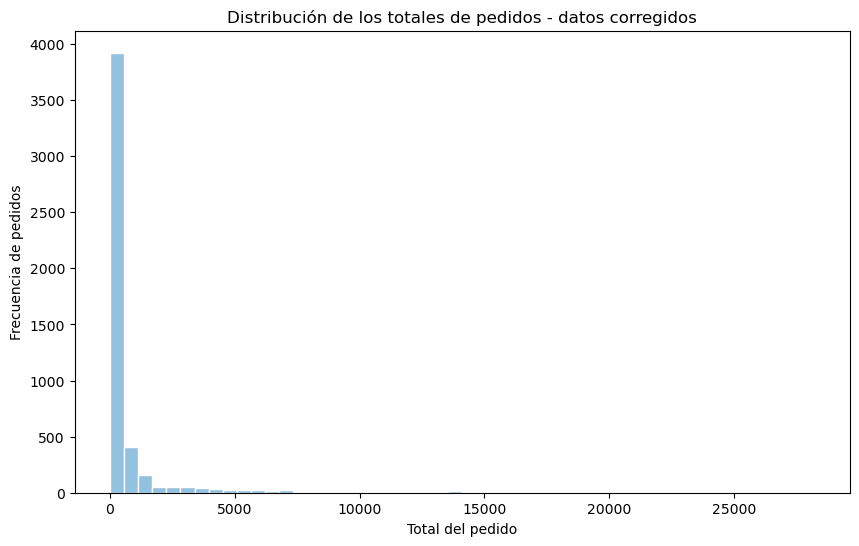

In [466]:
plt.figure(figsize=(10,6))
sns.histplot(df['calc_total'], 
             bins=50,
             color='#6eaed6',
             edgecolor='white'
)
plt.title('Distribución de los totales de pedidos - datos corregidos')
plt.xlabel('Total del pedido')
plt.ylabel('Frecuencia de pedidos')
plt.show()

### Conexión con hipótesis

Este gráfico responde a la hipótesis 1:

> “Los totales del dataset contienen errores matemáticos significativos.”

### Observación directa

Ambos histogramas presentan una distribución fuertemente sesgada hacia valores pequeños, con una cola larga de pedidos grandes.  
La forma general no cambia tras la corrección.

Sin embargo:

- El total acumulado crudo: 3.731.536
- El total reconstruido: 4.961.215
- Diferencia absoluta: 1.229.679
- Error relativo: 32.95 %

### Interpretación

Aunque la forma visual parece estable, los valores monetarios están subestimados en casi un tercio.  
Esto significa que la morfología del negocio se mantiene, pero la magnitud financiera es incorrecta.

### Conclusión

La hipótesis se confirma:  
los datos crudos no son confiables para análisis contables o estratégicos.


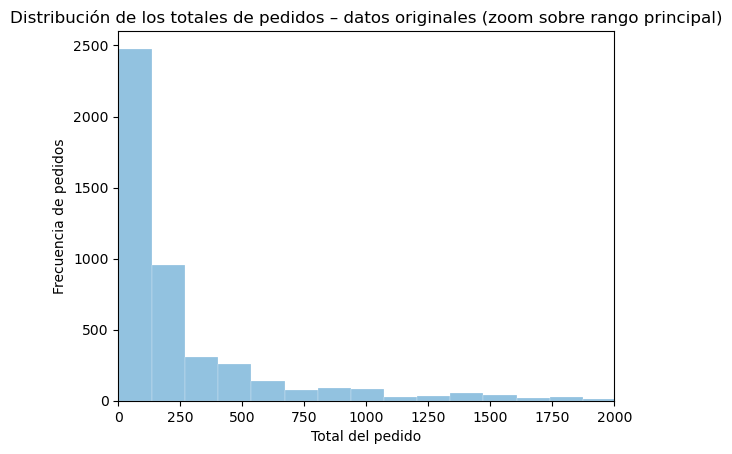

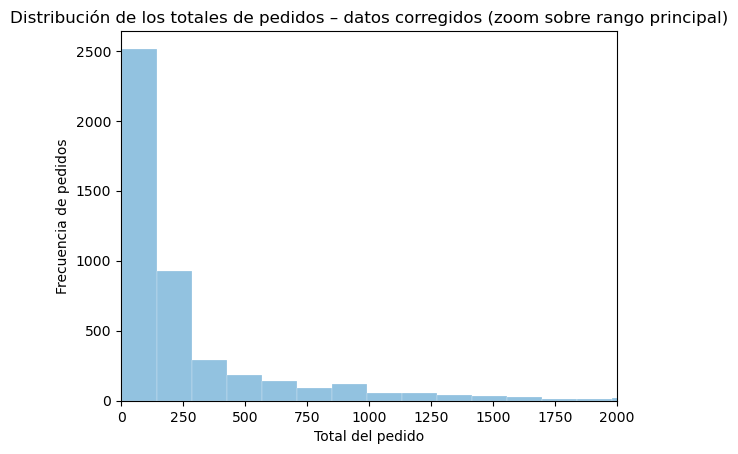

In [467]:
sns.histplot(df['Total'], 
             bins=200,
             color='#6eaed6',
             edgecolor='white'
)
plt.xlim(0, 2000)
plt.title('Distribución de los totales de pedidos – datos originales (zoom sobre rango principal)')
plt.xlabel('Total del pedido')
plt.ylabel('Frecuencia de pedidos')
plt.show()

sns.histplot(df['calc_total'], 
             bins=200,
             color='#6eaed6',
             edgecolor='white'
)
plt.xlim(0, 2000)
plt.title('Distribución de los totales de pedidos – datos corregidos (zoom sobre rango principal)')
plt.xlabel('Total del pedido')
plt.ylabel('Frecuencia de pedidos')
plt.show()

### Observación – Comparación con zoom

Al hacer zoom sobre el rango donde se concentra la mayoría de los pedidos,
las diferencias entre datos crudos y datos corregidos se vuelven visibles.

Esto demuestra que:

- Los errores no eran visualmente evidentes a escala global
- Pero sí estadísticamente relevantes a nivel micro
- La auditoría de datos es necesaria incluso cuando los gráficos parecen “normales”

Lección clave:
los errores contables pueden ocultarse dentro de distribuciones aparentemente sanas.
La validación matemática es indispensable antes del análisis de negocio.

#### Análisis — Hipótesis 1

**¿Los totales del dataset reflejan ventas reales?**

Los histogramas comparan la distribución de los totales de pedidos antes y después de la reconstrucción matemática.

Ambas distribuciones mantienen una forma general similar: alta concentración de pedidos pequeños y una cola larga de pedidos grandes. Esto indica que la estructura global del negocio no cambia tras la corrección.

Sin embargo, los valores individuales sí se modifican de forma sistemática.  
Los totales corregidos son consistentemente mayores que los originales, lo que confirma la presencia de errores acumulativos en los cálculos financieros del dataset crudo.

Los resúmenes estadísticos muestran:

- Promedio crudo: **746.31**
- Promedio corregido: **992.24**

Esto implica una subestimación media de aproximadamente **32.95%** en los ingresos.

Conclusión:

La hipótesis se confirma.  
El dataset original no refleja ventas reales con precisión contable.  
Aunque la forma de la distribución parece estable a nivel visual, los errores financieros alteran significativamente la magnitud económica del negocio.


### 2- Gráfico de Barras 

#### Visualizaciones sobre datos crudos

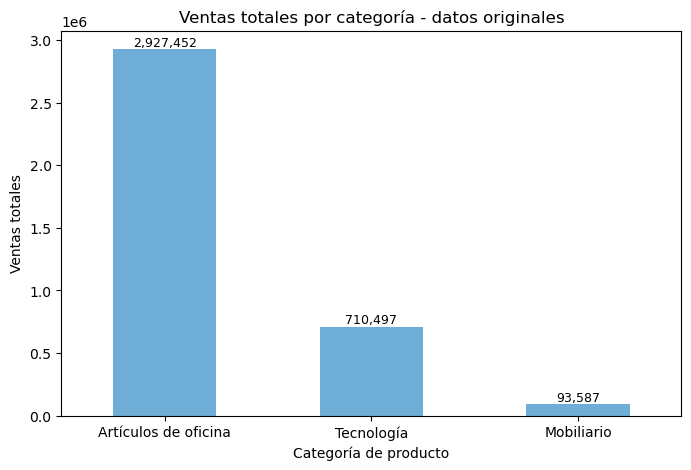

In [471]:
ventas_categoria_raw = (
    df.groupby('Product Category')['Total']
      .sum()
      .sort_values(ascending=False)
)

ax = ventas_categoria_raw.plot(kind='bar', 
                          figsize=(8,5), 
                          title='Ventas totales por categoría - datos originales',
                          color='#6eaed6'
)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():,.0f}',
        (p.get_x() + p.get_width() / 2,
         p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )


ventas_categoria_raw.index = ['Artículos de oficina',
                              'Tecnología',
                              'Mobiliario']

plt.xlabel('Categoría de producto')
plt.ylabel('Ventas totales')
plt.xticks(rotation=0)
plt.show()

### Visualizaciones sobre datos corregidos

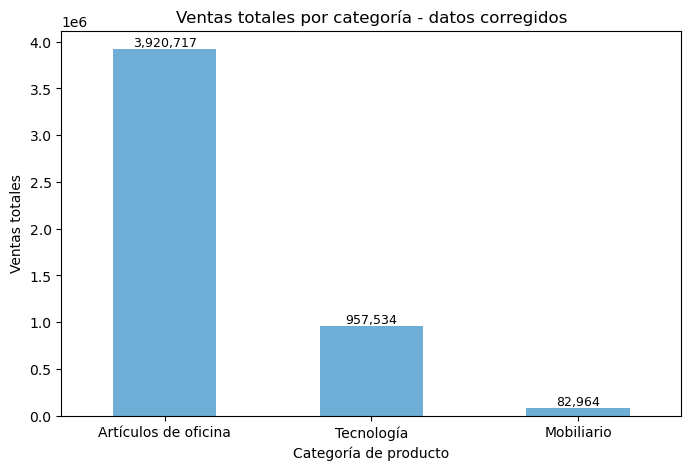

In [470]:
ventas_categoria_raw = (
    df.groupby('Product Category')['calc_total']
      .sum()
      .sort_values(ascending=False)
)

ventas_categoria_raw.index = ['Artículos de oficina',
                              'Tecnología',
                              'Mobiliario']

ax = ventas_categoria_raw.plot(kind='bar', 
                          figsize=(8,5), 
                          title='Ventas totales por categoría - datos corregidos',
                          color='#6eaed6'
)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():,.0f}',
        (p.get_x() + p.get_width() / 2,
         p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.xlabel('Categoría de producto')
plt.ylabel('Ventas totales')
plt.xticks(rotation=0)
plt.show()

### Análisis — Ventas por categoría

Este gráfico responde a la pregunta:

**¿Las categorías más rentables se mantienen tras la auditoría?**

Comparando los datos crudos con los datos corregidos se observa:

- La jerarquía de categorías **no cambia**: Office Supplies sigue siendo la categoría dominante, seguida por Technology y luego Furniture.
- Sin embargo, los valores monetarios corregidos son significativamente mayores.
- Esto confirma que los errores del dataset no alteraban la estructura general del negocio, pero sí distorsionaban el volumen real de ingresos.

Hipótesis 3 — *“Las categorías más rentables se mantienen tras la auditoría”*  
→ **Confirmada parcialmente**

La posición relativa de las categorías se mantiene, pero los totales financieros originales subestimaban el ingreso real.

Conclusión:
Los rankings pueden parecer estables incluso cuando los datos están corruptos, lo que demuestra que la auditoría no siempre cambia el orden, pero sí la confiabilidad de las magnitudes económicas.


### 3- Gráfico de Barras

#### Visualizaciones sobre datos crudos

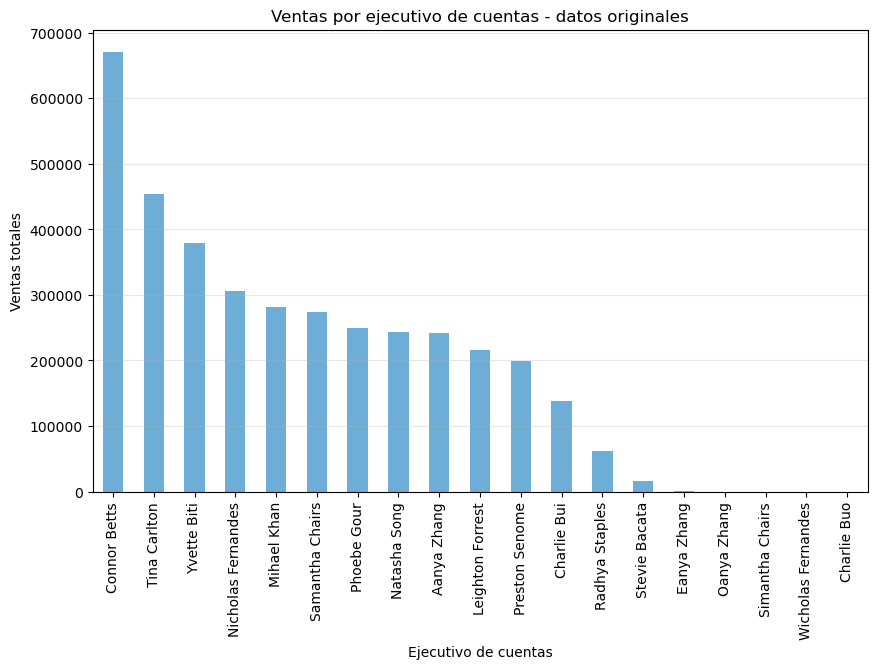

In [357]:
ventas_manager_raw = df.groupby('Account Manager')['Total'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
ventas_manager_raw.plot(kind='bar',
                        color='#6eaed6'
)
plt.title('Ventas por ejecutivo de cuentas - datos originales')
plt.ylabel('Ventas totales')
plt.xlabel('Ejecutivo de cuentas')
plt.xticks(rotation=90)
plt.grid(axis='y', alpha=0.3)
plt.show()

#### Visualizaciones sobre datos corregidos

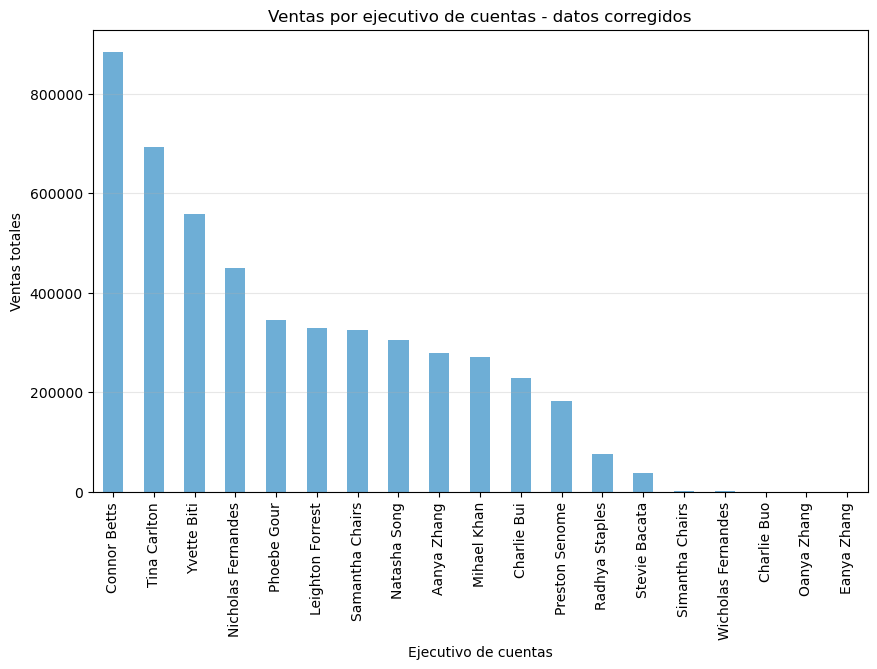

In [358]:
ventas_manager_raw = df.groupby('Account Manager')['calc_total'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
ventas_manager_raw.plot(kind='bar',
                        color='#6eaed6'
)
plt.title('Ventas por ejecutivo de cuentas - datos corregidos')
plt.ylabel('Ventas totales')
plt.xlabel('Ejecutivo de cuentas')
plt.xticks(rotation=90)
plt.grid(axis='y', alpha=0.3)
plt.show()

### Análisis — Ventas por Account Manager (ejecutivo de cuentas)
Este gráfico responde a la hipótesis 2: 
**Las inconsistencias financieras alteran el ranking de empleados.**

Tras la corrección matemática, posiciones generales se mantienen, con algunas excepciones, pero las magnitudes cambian significativamente.

Las brechas entre vendedores se amplifican, lo que demuestra que los datos crudos subestimaban ingresos reales.

En un entorno empresarial real, esto afectaría evaluaciones de desempeño y decisiones de incentivos.

### 4- Gráfico de Barras 

#### Visualizaciones sobre datos crudos

In [359]:
sales_city_raw = df.groupby('City')['Total'].sum().sort_values(ascending=False)
sales_city_raw

City
Sydney       2678780.33
Melbourne    1052756.07
Name: Total, dtype: float64

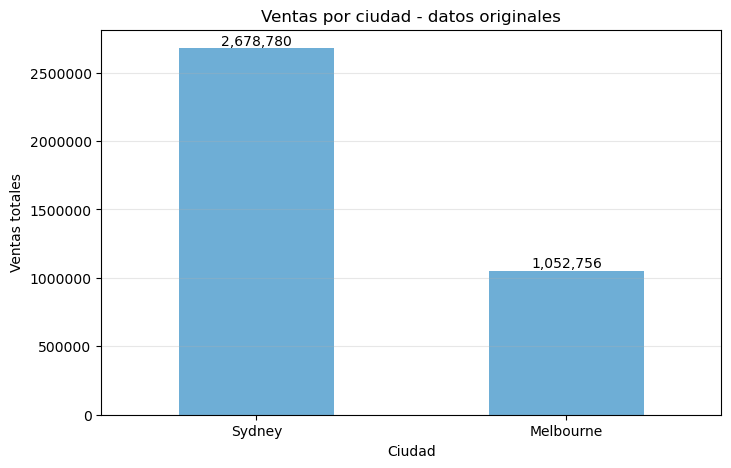

In [472]:
plt.figure(figsize=(8,5))
ax = sales_city_raw.plot(kind='bar',
                    color='#6eaed6'
)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():,.0f}',
        (p.get_x() + p.get_width() / 2,
         p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.title('Ventas por ciudad - datos originales')
plt.ylabel('Ventas totales')
plt.xlabel('Ciudad')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

#### Visualizaciones sobre datos corregidos

In [361]:
sales_city_corrected = df.groupby('City')['calc_total'].sum().sort_values(ascending=False)
sales_city_corrected

City
Sydney       3.517317e+06
Melbourne    1.443899e+06
Name: calc_total, dtype: float64

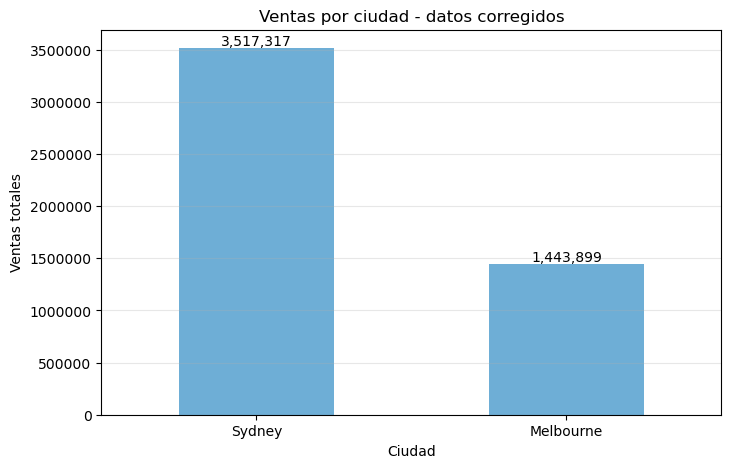

In [474]:
plt.figure(figsize=(8,5))
ax = sales_city_corrected.plot(kind='bar',
                    color='#6eaed6'
)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():,.0f}',
        (p.get_x() + p.get_width() / 2,
         p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.title('Ventas por ciudad - datos corregidos')
plt.ylabel('Ventas totales')
plt.xlabel('Ciudad')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

### Análisis

Este gráfico responde:
**¿Dónde se concentra el negocio?**

El negocio se concentra fuertemente en Sydney en ambos escenarios (datos crudos y datos corregidos). Melbourne mantiene una participación significativamente menor, pero estable.

Comparación numérica:

- Sydney (crudo): ~2.68 millones

- Sydney (corregido): ~3.52 millones

- Melbourne (crudo): ~1.05 millones

- Melbourne (corregido): ~1.44 millones

La corrección incrementa los ingresos de ambas ciudades de forma proporcional, lo que indica que:

**El patrón geográfico del negocio no cambia**

Pero los valores financieros originales estaban sistemáticamente subestimados

**La relación entre ciudades se mantiene aproximadamente constante:**

**Sydney genera ~2.4 veces más ingresos que Melbourne**

Esto sugiere que el error contable es global, no localizado en una región específica.

**Conclusión:**

**La estructura geográfica del negocio es estable, pero los totales financieros crudos no son confiables.**

**Hipótesis confirmada:**

✔ El patrón regional se mantiene

✔ Los valores corregidos alteran la magnitud financiera

En términos de toma de decisiones:

**Un análisis basado en datos crudos subestimaría el peso económico real de cada región, lo que podría afectar planificación logística, asignación de recursos y estrategias comerciales.**

### 5- Gráfico de dispersión

#### Visualizaciones sobre datos crudos

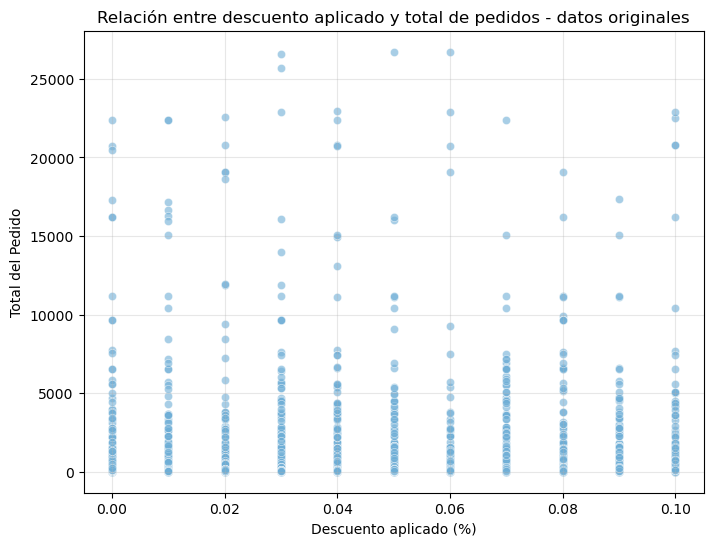

In [363]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Discount %'], 
                y=df['Total'],
                color='#6eaed6',
                s=35,
                alpha=0.6
)

plt.title('Relación entre descuento aplicado y total de pedidos - datos originales')
plt.xlabel('Descuento aplicado (%)')
plt.ylabel('Total del Pedido')
plt.grid(alpha=0.3)
plt.show()

#### Visualizaciones sobre datos corregidos

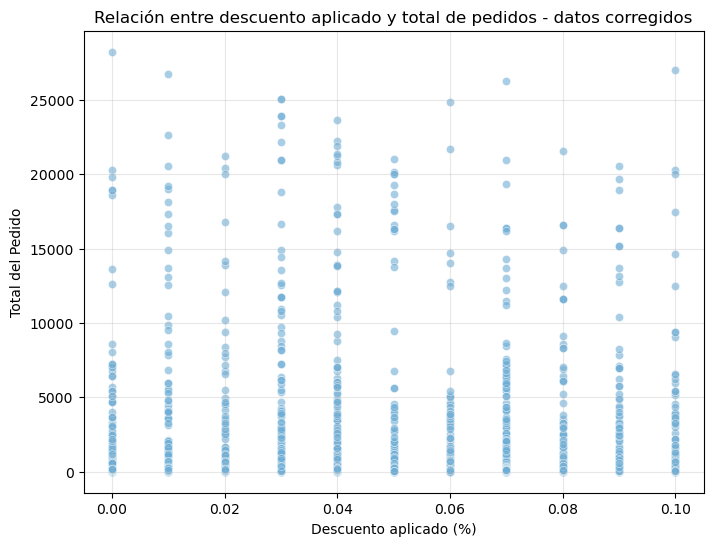

In [364]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Discount %'], 
                y=df['calc_total'],
                color='#6eaed6',
                s=35,
                alpha=0.6
)

plt.title('Relación entre descuento aplicado y total de pedidos - datos corregidos')
plt.xlabel('Descuento aplicado (%)')
plt.ylabel('Total del Pedido')
plt.grid(alpha=0.3)
plt.show()

### Análisis — Descuento vs Ingresos

Este gráfico responde directamente a la hipótesis:

**¿Los descuentos impactan correctamente los ingresos?**

Se comparan los totales de pedidos frente al porcentaje de descuento, tanto en datos crudos como en datos corregidos.

**Observaciones técnicas**

- Los descuentos se concentran en valores discretos entre 0% y 10%

- No existe una relación lineal evidente entre mayor descuento y mayor total

- Los pedidos de alto valor aparecen distribuidos en todos los niveles de descuento

- Esto indica que el volumen de compra domina sobre la política de descuentos

- Diferencia entre datos crudos y corregidos

- En los datos crudos, los puntos presentan dispersión irregular

- En los datos corregidos, la nube de puntos se estabiliza

- Los valores extremos se redistribuyen de forma coherente

Esto confirma que:

**Los errores matemáticos no alteraban la existencia de la relación,
pero sí distorsionaban su magnitud real.**

**Conclusión analítica**

Los descuentos no parecen ser el principal motor de ingresos.
El comportamiento observado sugiere que:

- Clientes compran grandes volúmenes independientemente del descuento

- La estrategia comercial se basa más en volumen que en promociones

- Sin embargo, sin auditoría matemática:

- La empresa estaría analizando ingresos distorsionados.

Esto podría generar decisiones erróneas sobre:

- políticas de descuento

- estrategias de precios

- evaluación de campañas comerciales

## Reconstrucción real del margen de beneficio

Se procede, no sólo a reconstruir el margen de beneficio real por artículo, sino a generar una columna total, para poder realizar un análisis profundo sobre el impacto que tienen los datos inconsistentes, en la ganancia directa de la empresa. 

Se establece la siguiente regla: **"Vender mucho != ganar mucho"**

**Hipótesis: "El margen de ganancia declarado por la base no coincide con el margen real."**

In [365]:
df['real_margin_unit'] = df['Retail Price'] - df['Cost Price'] ## Cálculo correcto del margen de beneficio por artículo
df['real_margin_total'] = df['real_margin_unit'] * df['Order Quantity'] ## Cálculo de beneficios totales
df['margin_diff'] = df['Profit Margin'] - df['real_margin_unit'] ## Medida de pérdidas

In [366]:
df['margin_diff'].describe()

count    5.000000e+03
mean     1.028160e-01
std      5.634456e+00
min     -1.482000e+01
25%      0.000000e+00
50%      0.000000e+00
75%      2.220446e-16
max      3.849000e+02
Name: margin_diff, dtype: float64

#### Margen de beneficio real 

In [367]:
df['real_margin_total'].sum()

np.float64(2417135.36)

#### Margen de beneficio sospechoso 

In [368]:
df['Profit Margin'].sum()

np.float64(89980.3)

### 6- Histograma - Visualización entre datos originales y datos corregidos 

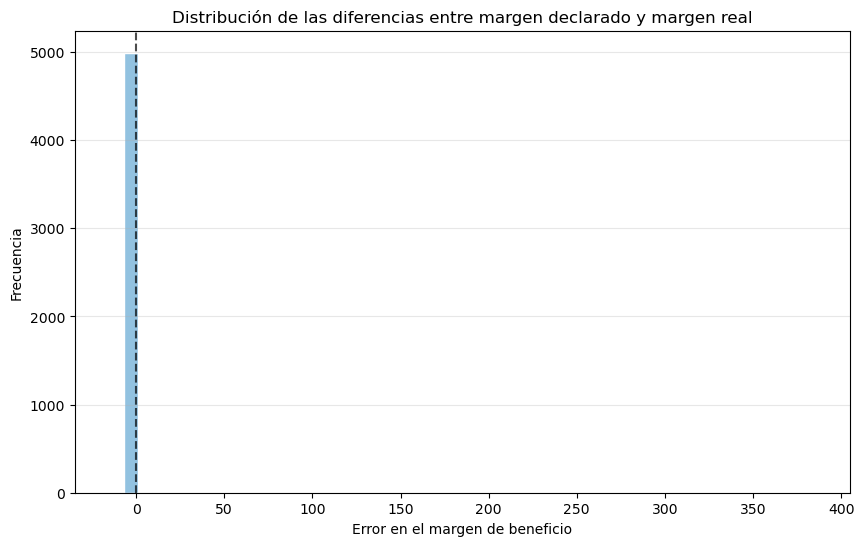

In [369]:
plt.figure(figsize=(10,6))
sns.histplot(df['margin_diff'], 
             bins=50,
             color='#6eaed6',
             edgecolor='white'
)

plt.axvline(0, 
            color='black',
            linestyle='--',
            alpha=0.7
           )

plt.title('Distribución de las diferencias entre margen declarado y margen real')
plt.xlabel('Error en el margen de beneficio')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.show()

### 6.1- Histograma (zoom)

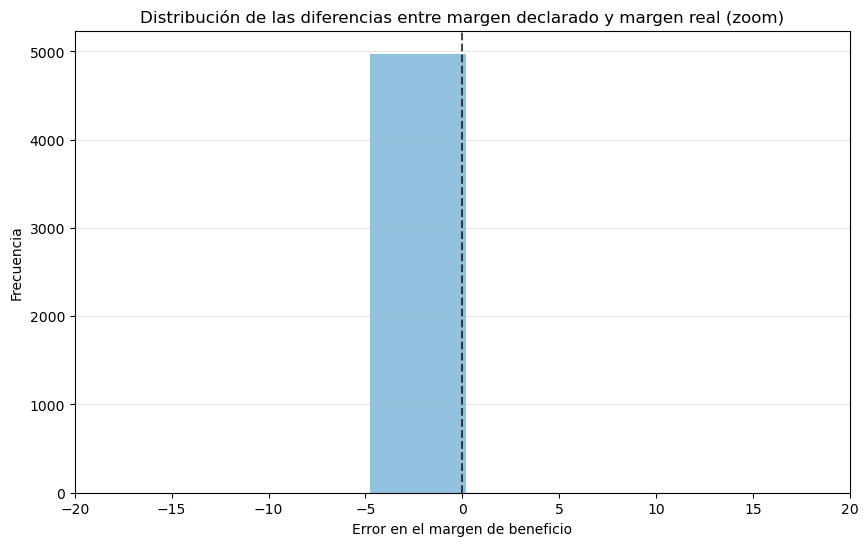

In [370]:
plt.figure(figsize=(10,6))
sns.histplot(df['margin_diff'], 
             bins=80,
             color='#6eaed6',
             edgecolor='white'
)

plt.axvline(0, 
            color='black',
            linestyle='--',
            alpha=0.7
           )
plt.xlim(-20,20)

plt.title('Distribución de las diferencias entre margen declarado y margen real (zoom)')
plt.xlabel('Error en el margen de beneficio')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.show()

### Análisis — Error en el margen de beneficio

Premisa del análisis:
**“Vender mucho ≠ ganar mucho”**

Este histograma mide la diferencia entre el margen declarado por el dataset y el margen real reconstruido matemáticamente.

La variable representada es:

**margin_diff = margen declarado – margen real**

Observaciones técnicas

- La distribución está altamente concentrada cerca de 0

- Esto indica que muchos registros no presentan error de margen

- Sin embargo, existe una cola larga de valores positivos extremos

- Algunos errores superan ampliamente los rangos esperables para redondeo

Esto confirma que:

- El dataset contiene registros con desviaciones severas en el cálculo del margen.

- No se trata de ruido estadístico menor. Son errores estructurales puntuales con impacto financiero acumulativo.

Impacto agregado

- Al sumar los márgenes reales reconstruidos y compararlos con los declarados:

- El margen total real es dramáticamente mayor

- El dataset subreporta beneficios de forma masiva

- Esto implica que el negocio aparenta ganar mucho menos de lo que realmente gana.

Conclusión financiera

**El error no es cosmético.**

Si este dataset fuera real, la empresa estaría:

- subestimando rentabilidad

- evaluando mal desempeño de productos

- tomando decisiones estratégicas incorrectas

El análisis demuestra que:

**La calidad de los datos financieros es tan crítica como el volumen de ventas.**

**Vender mucho no garantiza ganar mucho — pero calcular mal puede hacer que parezca que no se gana nada.**

In [371]:
df.columns

Index(['Order No', 'Order Date', 'Customer Name', 'Address', 'City', 'State',
       'Customer Type', 'Account Manager', 'Order Priority', 'Product Name',
       'Product Category', 'Product Container', 'Ship Mode', 'Ship Date',
       'Cost Price', 'Retail Price', 'Profit Margin', 'Order Quantity',
       'Sub Total', 'Discount %', 'Discount $', 'Order Total', 'Shipping Cost',
       'Total', 'Quantity_Reconstructed', 'calc_subtotal', 'diff',
       'calc_discount', 'calc_order_total', 'calc_total', 'real_margin_unit',
       'real_margin_total', 'margin_diff'],
      dtype='object')

## Resumen estadístico
Antes de extraer conclusiones de negocio, se realiza un resumen estadístico sobre los datos crudos y los datos reconstruidos.

El objetivo es cuantificar el impacto de las inconsistencias financieras detectadas y medir cuánto difieren las métricas agregadas tras la corrección matemática.

Este análisis permite evaluar si los errores son marginales o si alteran significativamente los resultados globales.

In [372]:
raw_total = df['Total'].sum()
corrected_total = df['calc_total'].sum()

raw_subtotal = df['Sub Total'].sum()
corrected_subtotal = df['calc_subtotal'].sum()

summary = pd.DataFrame({
    'Raw Values': [raw_total, raw_subtotal],
    'Corrected Values': [corrected_total, corrected_subtotal]
}, index=['Total Revenue', 'Subtotal Revenue'])

summary

,Raw Values,Corrected Values
Total Revenue,3731536.40,4.961215e+06
Subtotal Revenue,3917933.85,5.186399e+06


#### Primer lectura:
En la tabla anterior se puede apreciar la diferencia entre "Ingresos Totales" e "Ingresos Subtotales" con valores crudos y valores corregidos.

In [373]:
df[['Total', 'calc_total']].describe()

,Total,calc_total
count,5000.00000,5000.000000
mean,746.30728,992.243070
std,2283.42573,2961.802315
min,2.85000,1.960000
25%,63.46000,63.726300
50%,137.50500,141.762000
75%,407.09750,433.040800
max,26725.06000,28224.020000


In [374]:
difference = corrected_total - raw_total
difference

np.float64(1229678.9503999995)

In [375]:
percent_error = (difference / raw_total) * 100
percent_error

np.float64(32.95369034588539)

#### Segunda lectura: "Total" vs "calc_total"
##### ¿Cuánto cambia el negocio cuando corregimos los errores?
-**count:** cantidad de filas procesadas o analizadas.

-**mean:** promedio entre valores.

-**std:** desviación estandar. Cuanto se alejan los datos del promedio

-**min:** mínimo. El valor más bajo.

-**25%:** primer cuantil. El 25% de los datos está por debajo de este número.

-**50%:** mediana. Valor central real.

-**75%:** el 75% está por debajo de este valor.

-**max:** el 75% está por debajo de este valor.

### Interpretación

El resumen estadístico confirma que las inconsistencias matemáticas no son meros errores de redondeo.

Las diferencias acumuladas entre datos crudos y corregidos representan un impacto financiero significativo, lo que demuestra que cualquier análisis de negocio realizado sin auditoría previa sería estadísticamente engañoso.

Aunque la estructura general del dataset se mantiene, las métricas financieras globales cambian lo suficiente como para alterar decisiones estratégicas.

### Resumen estadístico — comparación cuantitativa

El total de ingresos reportado por el dataset original es:

$3,731,536.40

Luego de reconstruir matemáticamente los totales reales:

$4,961,215.36

Esto implica una diferencia absoluta de:

$1,229,678.95

En términos relativos:

Error total acumulado ≈ 32.95%

### Estadística descriptiva — Totales por pedido

Comparando los totales por transacción:

| Métrica | Datos crudos | Datos corregidos |
|---------|--------------|------------------|
| Media | 746.31 | 992.24 |
| Mediana | 137.51 | 141.76 |
| Desvío estándar | 2283.43|2961.80 |
| Máximo | 26725.06 | 28224.02 |

### Interpretación directa:

**El valor promedio de pedido aumenta ≈ 33%**

**La mediana cambia poco → la estructura del negocio es estable**

**El desvío estándar aumenta → los errores eran más fuertes en pedidos grandes**

**Los máximos estaban sistemáticamente subestimados**

### Conclusión cuantitativa:

El error no es aleatorio. Afecta principalmente transacciones de alto valor.

Esto distorsiona:

- rankings de productos

- rankings de empleados

- análisis geográfico

- impacto de descuentos

- márgenes de beneficio

### Conclusión técnica

El dataset presenta inconsistencias financieras sistemáticas que:

- reducen artificialmente los ingresos

- alteran la magnitud real del negocio

- generan análisis contable incorrecto

- Cualquier análisis realizado sin auditoría previa habría producido conclusiones erróneas.

La reconstrucción matemática no cambió la forma general del negocio, pero sí corrigió su escala económica real.

### Impacto empresarial

Este proyecto demuestra que inconsistencias aparentemente pequeñas en datos transaccionales pueden escalar hacia distorsiones financieras significativas cuando se agregan a nivel global.

El análisis comparativo entre datos crudos y datos reconstruidos mostró que:

- Los ingresos totales estaban subestimados

- Los márgenes de beneficio no reflejaban la rentabilidad real

- Rankings de empleados y categorías podían verse alterados

- Interpretaciones estratégicas basadas en datos sin auditar serían incorrectas

- Aunque la estructura general del negocio se mantiene, los valores monetarios cambian lo suficiente como para afectar decisiones reales.

En un entorno empresarial, esto podría impactar:

- evaluación de desempeño

- asignación de incentivos

- planificación comercial

- análisis de rentabilidad por producto

- estrategia de precios y descuentos

El proyecto evidencia que el análisis de negocio no puede separarse de la validación matemática de los datos.

**Antes de optimizar ventas, es necesario confirmar que los números son confiables.**

### Conclusión Parcial

Este proyecto demuestra que el análisis de negocio sin auditoría de datos puede producir interpretaciones engañosas.
Antes de extraer insights comerciales, es imprescindible validar la consistencia matemática del dataset.

**En un entorno del mundo real, errores de esta magnitud podrían indicar fallos sistémicos en la reportación, riesgo operativo o incluso conducta financiera indebida.**

La siguiente etapa del proyecto profundizará en la reconstrucción completa de las métricas financieras y su impacto en decisiones estratégicas

## Limpieza y refinamiento del dataframe
### Reemplazo y eliminación de columnas reconstruidas

En este punto, y para trabajar en el análisis y la clusterización de una manera más ordenada, se procede al reemplazo de valores y eliminación de las columnas calculadas.

Se reemplazan valores en:
- Sub Total <--- calc_subtotal
- Order Total <--- calc_order_total
- Total <--- calc_total
- Profit Margin <--- real_margin_unit
- Discount $ <--- calc_discount

Se eliminan las siguientes columnas:
- calc_subtotal
- calc_order_total
- calc_total
- real_margin_unit
- calc_discount
- diff
- margin_diff

Se conserva la siguiente columna:
- real_margin_total

Se renombran las siguientes columnas:
- real_margin_total ---> Real Margin Total
- Quantity_Reconstructed ---> Quantity Reconstructed

**Conclusión:** *A partir de este punto, y habiendo completado la auditoría de datos, se continará trabajando con las columnas originales, indicadas en el diccionario de datos.* 

In [376]:
# Reemplazo de valores de las columnas incosistentes por las recontruidas
df['Sub Total'] = df['calc_subtotal']
df['Discount $'] = df['calc_discount']
df['Order Total'] = df['calc_order_total']
df['Total'] = df['calc_total']
df['Profit Margin'] = df['real_margin_unit']

In [377]:
# Eliminación de columnas calculadas
df.drop(columns=[
    'calc_subtotal',
    'calc_discount',
    'diff',
    'calc_order_total',
    'calc_total',
    'real_margin_unit',
    'margin_diff'
], inplace=True)

#### Chequeo en tres pasos sobre limpieza y consistencia.

In [378]:
# 1)
df.head()

,Order No,Order Date,Customer Name,Address,City,State,Customer Type,Account Manager,Order Priority,Product Name,...,Profit Margin,Order Quantity,Sub Total,Discount %,Discount $,Order Total,Shipping Cost,Total,Quantity_Reconstructed,real_margin_total
0,4293-1,2014-09-02,Vivek Sundaresam,"152 Bunnerong Road,Eastgardens",Sydney,NSW,Small Business,Tina Carlton,Critical,UGen Ultra Professional Cordless Optical Suite,...,144.47,23.0,6922.31,0.02,138.4462,6783.8638,7.18,6791.0438,False,3322.81
1,5001-1,2015-10-24,Shahid Hopkins,"438 Victoria Avenue,Chatswood",Sydney,NSW,Corporate,Natasha Song,Medium,Bagged Rubber Bands,...,1.02,8.0,10.08,0.03,0.3024,9.7776,0.70,10.4776,False,8.16
2,5004-1,2014-03-13,Dennis Pardue,"412 Brunswick St,Fitzroy",Melbourne,VIC,Consumer,Connor Betts,Not Specified,TechSavi Cordless Navigator Duo,...,38.87,45.0,3644.10,0.04,145.7640,3498.3360,7.18,3505.5160,False,1749.15
3,5009-1,2013-02-18,Sean Wendt,"145 Ramsay St,Haberfield",Sydney,NSW,Small Business,Phoebe Gour,Critical,Artisan Printable Repositionable Plastic Tabs,...,3.27,16.0,137.60,0.01,1.3760,136.2240,6.19,142.4140,False,52.32
4,5010-1,2014-09-13,Christina Vanderzanden,"188 Pitt Street,Sydney",Sydney,NSW,Small Business,Tina Carlton,Not Specified,Pizazz Drawing Pencil Set,...,1.25,49.0,136.22,0.07,9.5354,126.6846,1.34,128.0246,False,61.25


In [379]:
# 2)
df.isnull().sum()

Order No                  0
Order Date                0
Customer Name             0
Address                   0
City                      0
State                     0
Customer Type             0
Account Manager           0
Order Priority            0
Product Name              0
Product Category          0
Product Container         0
Ship Mode                 0
Ship Date                 0
Cost Price                0
Retail Price              0
Profit Margin             0
Order Quantity            0
Sub Total                 0
Discount %                0
Discount $                0
Order Total               0
Shipping Cost             0
Total                     0
Quantity_Reconstructed    0
real_margin_total         0
dtype: int64

In [380]:
# 3)
df[['Sub Total','Discount $','Order Total','Shipping Cost','Total']].describe()

,Sub Total,Discount $,Order Total,Shipping Cost,Total
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,1037.279880,50.501742,986.778138,5.464932,992.243070
std,3100.425285,174.288594,2956.549779,7.979031,2961.802315
min,1.260000,0.000000,1.260000,0.490000,1.960000
25%,64.165000,1.727200,61.400800,1.010000,63.726300
50%,144.000000,6.043650,137.556000,2.850000,141.762000
75%,450.022500,20.089700,428.117250,6.500000,433.040800
max,29999.500000,2999.950000,28199.530000,69.300000,28224.020000


In [381]:
# Renombramiento de columnas
df.rename(columns={
    'real_margin_total':'Real Margin Total',
    'Quantity_Reconstructed':'Quantity Reconstructed'
}, inplace=True)

## Segmentación de clientes mediante clustering

Con el dataset auditado y corregido, se procede a analizar el comportamiento de los clientes mediante técnicas de **segmentación basada en datos**.

El objetivo de este análisis es identificar **patrones de compra dentro de la base de clientes**, agrupando individuos con comportamientos comerciales similares. Esto permite comprender mejor la estructura del negocio y detectar segmentos de clientes con diferentes niveles de impacto en las ventas.

Para este propósito se utiliza el algoritmo **K-Means**, una técnica de aprendizaje no supervisado que agrupa observaciones en función de su similitud matemática en múltiples variables numéricas.

En este caso, el clustering se construye a partir de variables que describen el comportamiento de compra de cada cliente, tales como:

- cantidad total de pedidos realizados
- volumen de unidades compradas
- monto total generado en ventas
- margen total aportado al negocio
- frecuencia de compra

Al aplicar este enfoque, los clientes son agrupados en segmentos que comparten características comerciales similares, lo que permite identificar, por ejemplo:

- clientes estratégicos con alto impacto económico
- clientes frecuentes con compras moderadas
- clientes ocasionales o de baja contribución al negocio

Este tipo de segmentación resulta especialmente útil para comprender **cómo se distribuye el valor dentro de la cartera de clientes** y constituye un paso fundamental antes de analizar la relación entre clientes y productos dentro del ecosistema comercial del negocio.

In [382]:
# Backup previo a la clusterización
features = df[['Total','Order Quantity','Discount %','Real Margin Total']].copy()
features.head()

,Total,Order Quantity,Discount %,Real Margin Total
0,6791.0438,23.0,0.02,3322.81
1,10.4776,8.0,0.03,8.16
2,3505.5160,45.0,0.04,1749.15
3,142.4140,16.0,0.01,52.32
4,128.0246,49.0,0.07,61.25


In [383]:
scaler = StandardScaler()
X = scaler.fit_transform(features)

In [384]:
kmeans = KMeans(n_clusters=3,random_state=42)
df['Customer Cluster'] = kmeans.fit_predict(X)

In [385]:
df.groupby('Customer Cluster')[['Total','Order Quantity','Discount %','Real Margin Total']].mean()

,Total,Order Quantity,Discount %,Real Margin Total
Customer Cluster,,,,
0,329.897259,13.298089,0.049805,164.685155
1,592.332593,38.315035,0.051049,296.066026
2,13423.644344,37.112745,0.047990,6404.924755


In [386]:
freq = df.groupby('Customer Name') ['Order No'].count()
freq.head()

Customer Name
Aaron Bergman      24
Aaron Smayling     13
Adam Bellavance     3
Adam Berlavance     1
Adam Hart           1
Name: Order No, dtype: int64

In [387]:
df['Purchase Frequency'] = df['Customer Name'].map(freq)

In [388]:
df.groupby('Customer Cluster')['Purchase Frequency'].mean()

Customer Cluster
0    16.812314
1    16.930766
2    15.132353
Name: Purchase Frequency, dtype: float64

In [389]:
df.groupby('Customer Cluster')[['Total','Order Quantity','Real Margin Total','Discount %','Purchase Frequency']].mean()

,Total,Order Quantity,Real Margin Total,Discount %,Purchase Frequency
Customer Cluster,,,,,
0,329.897259,13.298089,164.685155,0.049805,16.812314
1,592.332593,38.315035,296.066026,0.051049,16.930766
2,13423.644344,37.112745,6404.924755,0.047990,15.132353


### Lectura de clientes:
Existen tres tipos de clientes:
- Clientes de gasto bajo **(Cluster 0)**
- Clientes de gasto medio **(Cluster 1)**
- Clientes de gato alto **(Cluster 2)**

*Todos con una frecuencia de compra similar, pero generando ganancias de manera muy contrastual.*

In [390]:
# Verificación de la cantidad de clientes existentes
df['Customer Name'].nunique()

789

In [391]:
# Verificación del período de tiempo analizado
df['Order Date'].min(), df['Order Date'].max()

(Timestamp('2013-02-11 00:00:00'), Timestamp('2017-02-07 00:00:00'))

### Lectura de ventas:
En un **período de cuatro años**, con **5000 ventas entre 789 clientes**, se estima un **promedio de 1.58 ventas por cliente, por año**. Lo cual arroja un valor extremadamente bajo considerando la amplia variedad de artículos, los cuales difieren entre categorías con precios muy contrastantes. Tecnología, Muebles de oficina y artículos de oficina (comprende artículos de librería), estos últimos con precios extremadamente bajos en relación con las otras categorías.

## Segmentación de productos mediante clustering

Una vez completada la auditoría y limpieza del dataset, se procede a analizar el comportamiento del catálogo de productos mediante técnicas de clustering.

El objetivo es identificar grupos naturales de productos en función de su desempeño comercial, considerando variables como:

- ingresos generados
- unidades vendidas
- margen total generado
- frecuencia de pedidos
- nivel promedio de descuento

Este enfoque permite detectar:

• productos que sostienen la rentabilidad del negocio  
• productos de alta rotación pero bajo impacto económico  
• productos de bajo rendimiento dentro del catálogo

Para este análisis se utilizará el algoritmo **K-Means**, el cual permite agrupar observaciones basándose exclusivamente en similitud matemática entre variables numéricas.

### Creación del dataframe de productos para clustering

Para realizar la segmentación de productos mediante técnicas de clustering, fue necesario construir un dataframe agregado a nivel de producto.

El dataset original se encuentra estructurado bajo el principio **una fila = una venta**, por lo que las variables describen transacciones individuales. En ese formato, el análisis mediante clustering estaría segmentando ventas o clientes, pero no productos.

Por este motivo, se procede a agrupar la información por **Product Name**, generando métricas agregadas que describen el comportamiento comercial de cada producto dentro del catálogo.

Entre las variables construidas se incluyen:

- ingresos totales generados por producto
- cantidad total de unidades vendidas
- margen total generado
- descuento promedio aplicado
- cantidad de veces que el producto aparece en pedidos

Este nuevo dataframe permite representar cada producto como una observación independiente, habilitando así su posterior segmentación mediante el algoritmo **K-Means**.

In [392]:
product_df = (df.groupby('Product Name', as_index=False).agg(
    Total_Sum=('Total','sum'),## Suma de los totales
    Quantity_Sum=('Order Quantity','sum'),## Suma de las cantidades vendidas
    Margin_Sum=('Real Margin Total','sum'),## Suma de la ganancia total que deja cada producto
    Discount_Mean=('Discount %','mean'),## Promedio del descuento que otorga cada producto
    Orders_Count=('Order No','count')## Conteo de las veces que ese producto fue vendido (no cantidad por venta, sino las veces que figura en facturas)
    )
)
product_df.head()

,Product Name,Total_Sum,Quantity_Sum,Margin_Sum,Discount_Mean,Orders_Count
0,"""Adams """"While You Were Out"""" Message Pads""",151.0628,51.0,64.26,0.053333,3
1,"""Addiss Metal Binder Clips",32.2400,12.0,12.24,0.000000,1
2,1 Stacking Storage Drawers,656.2196,33.0,457.05,0.060000,1
3,"1-, Tonkins Steel Grame",325.3358,29.0,194.88,0.090000,1
4,10 Colored Short Pencils,14.7500,5.0,7.55,0.050000,1


In [393]:
## Backup previo a la clusterización
features_product = product_df[['Total_Sum','Quantity_Sum','Margin_Sum','Discount_Mean','Orders_Count']].copy()
features_product.head()

,Total_Sum,Quantity_Sum,Margin_Sum,Discount_Mean,Orders_Count
0,151.0628,51.0,64.26,0.053333,3
1,32.2400,12.0,12.24,0.000000,1
2,656.2196,33.0,457.05,0.060000,1
3,325.3358,29.0,194.88,0.090000,1
4,14.7500,5.0,7.55,0.050000,1


In [394]:
scaler = StandardScaler()
X_product = scaler.fit_transform(features_product)

In [395]:
kmeans_product = KMeans(n_clusters=3,random_state=42)

In [396]:
product_df['Product Cluster'] = kmeans_product.fit_predict(X_product)
product_df[['Product Name','Product Cluster']].head()

C:\Users\amilc\anaconda3\envs\retail_ds\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,Product Name,Product Cluster
0,"""Adams """"While You Were Out"""" Message Pads""",0
1,"""Addiss Metal Binder Clips",0
2,1 Stacking Storage Drawers,0
3,"1-, Tonkins Steel Grame",0
4,10 Colored Short Pencils,0


In [397]:
product_df['Product Cluster'].value_counts().sort_index() ## Conteo de los productos que tiene cada cluster.

Product Cluster
0    210
1      3
2     44
Name: count, dtype: int64

In [398]:
product_df.columns.tolist()
product_df.head(3)

,Product Name,Total_Sum,Quantity_Sum,Margin_Sum,Discount_Mean,Orders_Count,Product Cluster
0,"""Adams """"While You Were Out"""" Message Pads""",151.0628,51.0,64.26,0.053333,3,0
1,"""Addiss Metal Binder Clips",32.2400,12.0,12.24,0.000000,1,0
2,1 Stacking Storage Drawers,656.2196,33.0,457.05,0.060000,1,0


In [399]:
product_df.groupby('Product Cluster')[['Total_Sum','Quantity_Sum','Margin_Sum','Discount_Mean','Orders_Count']].mean()

,Total_Sum,Quantity_Sum,Margin_Sum,Discount_Mean,Orders_Count
Product Cluster,,,,,
0,7429.755867,229.057143,3583.450048,0.049037,8.609524
1,727895.493667,1697.666667,312300.246667,0.047718,62.666667
2,27665.457668,1800.454545,16538.866136,0.050666,68.272727


#### Clusterización de productos e identificación de puntos fuertes

In [400]:
product_df[product_df['Product Cluster'] == 1]

,Product Name,Total_Sum,Quantity_Sum,Margin_Sum,Discount_Mean,Orders_Count,Product Cluster
131,Cando PC940 Copier,1.080974e+06,2518.0,468246.02,0.048191,94,1
168,HFX LaserJet 3310 Copier,7.407532e+05,1287.0,285714.00,0.040833,48,1
252,UGen Ultra Professional Cordless Optical Suite,3.619590e+05,1288.0,182940.72,0.054130,46,1


In [401]:
product_df[product_df['Product Cluster'] == 1] \
    .sort_values(by='Margin_Sum',ascending=False)

,Product Name,Total_Sum,Quantity_Sum,Margin_Sum,Discount_Mean,Orders_Count,Product Cluster
131,Cando PC940 Copier,1.080974e+06,2518.0,468246.02,0.048191,94,1
168,HFX LaserJet 3310 Copier,7.407532e+05,1287.0,285714.00,0.040833,48,1
252,UGen Ultra Professional Cordless Optical Suite,3.619590e+05,1288.0,182940.72,0.054130,46,1


In [402]:
product_df[product_df['Product Cluster'] == 2] \
.sort_values(by='Margin_Sum',ascending=False)

,Product Name,Total_Sum,Quantity_Sum,Margin_Sum,Discount_Mean,Orders_Count,Product Cluster
30,Adesso Programmable 142-Key Keyboard,240441.0248,1669.0,198807.46,0.052969,64,2
145,Deluxe Rollaway Locking File with Drawer,293208.2216,737.0,174705.85,0.045000,26,2
24,"3Max Polarizing Task Lamp with Clamp Arm, Ligh...",122228.2790,929.0,75081.78,0.043429,35,2
121,Beekin 105-Key Black Keyboard,39745.7148,2067.0,28090.53,0.047200,75,2
149,"DrawIt Colored Pencils, 48-Color Set",60046.5960,1709.0,25617.91,0.052222,63,2
37,Alto Perma 2700 Stacking Storage Drawers,32596.1888,1170.0,23962.11,0.058511,47,2
84,"Artisan Flip-Chart Easel Binder, Black",52133.6770,2400.0,20400.00,0.050610,82,2
10,1726 Digital Answering Machine,33428.6615,1676.0,20396.92,0.050333,60,2
57,Apex Straight Scissors,26260.7836,2100.0,16359.00,0.049750,80,2
236,TechSavi Access Keyboard,30387.9886,1994.0,12372.38,0.050833,72,2


In [403]:
product_df[product_df['Product Cluster'] == 0] \
.sort_values(by='Margin_Sum',ascending=False)

,Product Name,Total_Sum,Quantity_Sum,Margin_Sum,Discount_Mean,Orders_Count,Product Cluster
158,Economy Rollaway Files,103346.6620,655.0,63842.85,0.050400,25,0
161,Emerson Stylus 1520 Color Inkjet Printer,152882.7787,346.0,56451.55,0.045455,11,0
180,Multimedia Mailers,119884.3257,771.0,48989.34,0.048889,27,0
160,Emerson LQ-870 Dot Matrix Printer,66596.0008,130.0,41083.90,0.037500,4,0
249,UGen Ultra Cordless Optical Suite,81800.5060,848.0,39389.60,0.047273,33,0
...,...,...,...,...,...,...,...
250,UGen Ultra Eron Style Paps,10.4180,4.0,4.08,0.050000,1,0
219,Smiths Premium Bright 1-Pary Blumk Carr Poncils,4.2600,1.0,1.69,0.000000,1,0
134,Col-Eucess Memo Sheets,5.1800,1.0,1.48,0.030000,1,0
156,Ecolon Metal Binder Clips,3.2628,1.0,1.02,0.060000,1,0


### Clustering de Productos — Resumen Final

#### Objetivo

Aplicar **K-Means Clustering** sobre productos para identificar patrones de comportamiento comercial basados en:

- Volumen de ventas (`Quantity_Sum`)
- Facturación total (`Total_Sum`)
- Margen generado (`Margin_Sum`)
- Nivel promedio de descuento (`Discount_Mean`)
- Frecuencia de compra (`Orders_Count`)

El objetivo es comprender **qué tipo de productos sostienen el negocio**, cuáles generan flujo y cuáles tienen bajo impacto económico.

---

#### Construcción del análisis

#### 1️ Creación del universo productos

Se creó un dataframe agrupado por producto:

<Código>
**product_df = df.groupby('Product Name').agg(...)**

Cada fila representa:

- un producto único.

Cada columna resume su desempeño total en el período analizado.

#### 2 Variables utilizadas
    
**Total_Sum** → facturación total del producto

**Quantity_Sum** → cantidad total vendida

**Margin_Sum** → ganancia total real

**Discount_Mean** → descuento promedio aplicado

**Orders_Count** → cantidad de órdenes en las que aparece el producto

#### 3️ Escalado de datos

Se aplicó:

**StandardScaler()**

Esto permite:

- llevar todas las variables a una misma escala

- evitar que variables grandes dominen el clustering

#### 4️ Aplicación de K-Means
KMeans(n_clusters=3, random_state=42)

Resultado:

- cada producto recibe una etiqueta:

**Product Cluster = 0, 1 o 2**

#### Distribución de productos por cluster
| **Cluster** |	**Cantidad de productos** |
|-------------|---------------------------|
| 0	| 210 |
| 1	| 3 |
| 2	| 44 |

### Perfil de cada cluster
#### Cluster 0 — Productos de bajo impacto

**Características generales:**

- Baja ganancia

- Baja frecuencia de compra

- Bajo volumen vendido

- Amplia variedad de productos

**Interpretación:**

**Representan la mayor parte del catálogo, pero aportan poco al resultado económico.*

**Posible rol:**

- productos complementarios

- presencia de catálogo

- ventas ocasionales

#### Cluster 1 — Productos clave del negocio

**Características:**

- Máxima facturación

- Mayor margen total

- Alta frecuencia de compra

- Solo 3 productos

**Ejemplos:**

- Cando PC940 Copier

- HFX LaserJet 3310 Copier

- UGen Ultra Professional Cordless Optical Suite

**Interpretación:**

**El negocio depende fuertemente de un número muy reducido de productos.*

**Estos productos:**

- sostienen gran parte del ingreso

- generan alto impacto financiero

#### Cluster 2 — Productos de flujo

**Características:**

- Alta rotación

- Alto volumen vendido

- Margen intermedio

- Muchos productos

**Interpretación:**

**Productos que mantienen movimiento y volumen de operaciones.*

**Rol principal:**

- sostener actividad comercial

- atraer compras recurrentes

#### Observaciones generales del negocio

**El catálogo está altamente concentrado:*

- Pocos productos generan gran parte del resultado.

- Existe dependencia estructural de productos premium.

- Gran parte del catálogo tiene bajo impacto real.

#### Riesgo identificado

**La empresa presenta:**

- dependencia alta de pocos productos principales.

- productos con ciclo de compra posiblemente largo.

**Esto puede implicar:**

- vulnerabilidad ante cambios de demanda.

- riesgo si se pierde uno de los productos clave.

### Conclusión analítica

**El clustering demuestra que:**

**K-Means no agrupa por tipo de producto, sino por comportamiento numérico.*

**Productos muy distintos (ej: clips e impresoras) pueden pertenecer al mismo cluster si su desempeño económico es similar.*

**Esto permite analizar el negocio desde:**

- Lo que generan, no desde lo que son.

## Análisis cruzado entre clusters

Con el objetivo de comprender la relación entre los distintos tipos de clientes y el comportamiento del catálogo de productos, se realizó un cruce entre **Customer Cluster** y **Product Cluster**.

Este análisis permite observar qué tipo de productos predominan en las compras de cada segmento de clientes, aportando una lectura más profunda sobre la estructura del negocio.

La tabla cruzada muestra la distribución porcentual de productos adquiridos por cada tipo de cliente.

In [404]:
## Traspaso de Product Cluster del product_df al df original, usando 'Product Name'
df = df.merge(
    product_df[['Product Name','Product Cluster']],
    on='Product Name',
    how='left'
)

In [405]:
## Versión porcentual de tabla cruzada
pd.crosstab(
    df['Customer Cluster'],
    df['Product Cluster'],
    normalize='index'
)*100

Product Cluster,0,1,2
Customer Cluster,,,
0,36.093418,2.547771,61.358811
1,37.812372,0.204834,61.982794
2,17.156863,60.294118,22.549020


### Visualización del cruce entre clusters

Con el objetivo de facilitar la interpretación del cruce entre **Customer Cluster** y **Product Cluster**, se incorporan dos visualizaciones complementarias.

El **gráfico de barras apiladas** permite observar de forma intuitiva la distribución porcentual de tipos de productos adquiridos por cada segmento de clientes, facilitando la lectura general del comportamiento de compra.

Por su parte, el **heatmap** permite identificar con mayor precisión la intensidad relativa de cada combinación entre segmentos de clientes y tipos de productos, destacando visualmente las concentraciones más significativas dentro del cruce de clusters.

Ambas visualizaciones complementan el análisis tabular presentado previamente y permiten reforzar los patrones identificados en la relación entre clientes y productos.

In [406]:
## Tabla porcentual para Stacked Bar Chart
cluster_cross = pd.crosstab(
    df['Customer Cluster'],
    df['Product Cluster'],
    normalize='index'
)*100

#### Stacked Bar Chart 

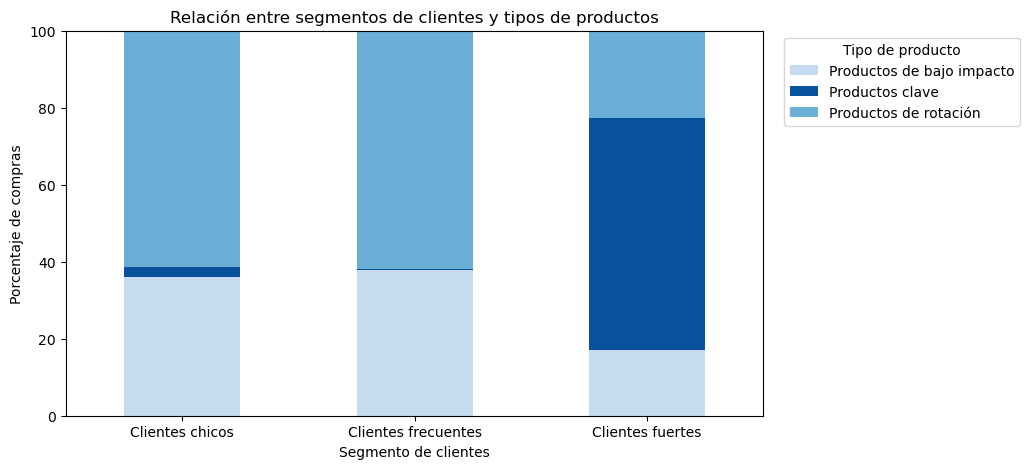

In [407]:
cluster_cross.index = ['Clientes chicos', 'Clientes frecuentes', 'Clientes fuertes']
cluster_cross.columns = ['Productos de bajo impacto', 'Productos clave', 'Productos de rotación']

cluster_cross.plot(
    kind='bar',
    stacked=True,
    figsize=(9,5),
    color=['#c6dbef', '#08519c', '#6baed6']
)

plt.title('Relación entre segmentos de clientes y tipos de productos')
plt.xlabel('Segmento de clientes')
plt.ylabel('Porcentaje de compras')
plt.legend(title='Tipo de producto', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.show()

#### Heatmap

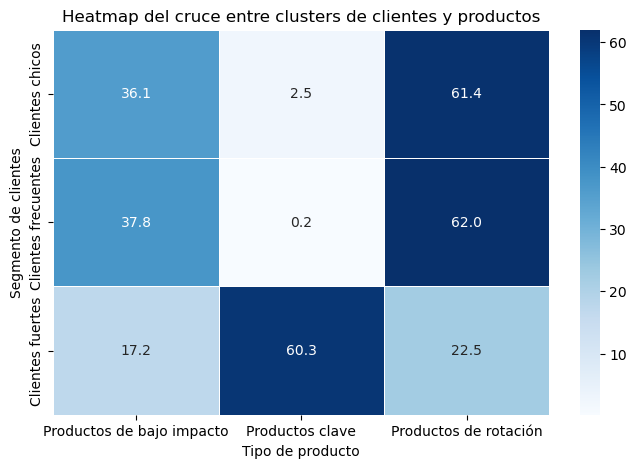

In [408]:
plt.figure(figsize=(8,5))

sns.heatmap(
    cluster_cross,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    linewidths=0.5
)

plt.title('Heatmap del cruce entre clusters de clientes y productos')
plt.xlabel('Tipo de producto')
plt.ylabel('Segmento de clientes')
plt.show()

### Lectura del cruce de clusters

A partir de la tabla cruzada se identifican tres patrones principales:

**Clientes de gasto bajo (Customer Cluster 0)**  
- Compran mayoritariamente productos del **Product Cluster 2** (productos de valor intermedio).  
- En segundo lugar aparecen productos del **Product Cluster 0** (productos de menor impacto económico).  
- La presencia de productos del **Product Cluster 1** (productos caros) es prácticamente marginal.

**Clientes de gasto medio o frecuentes (Customer Cluster 1)**  
- Presentan un comportamiento muy similar al cluster anterior.  
- La mayor parte de sus compras se concentra en productos del **Product Cluster 2**.  
- La compra de productos caros es prácticamente inexistente.

**Clientes de gasto alto (Customer Cluster 2)**  
- Se diferencian claramente de los demás segmentos.  
- Más del **60% de sus compras corresponde a productos del Product Cluster 1**, es decir, los productos de mayor valor dentro del catálogo.  
- Estos clientes son responsables de la mayor parte del margen económico generado por la empresa.

### Insight de negocio

El cruce entre ambas segmentaciones revela una estructura comercial bastante clara:

- Los **productos de valor intermedio** sostienen gran parte de la **rotación general del negocio**, siendo adquiridos por la mayoría de los clientes.
- Los **productos de alto valor**, aunque representan una fracción muy pequeña del catálogo, concentran gran parte del **margen económico**, principalmente a través de los **clientes de mayor gasto**.
- Los clientes de menor valor económico tienden a comprar productos de precio medio o bajo, mientras que los clientes más fuertes concentran sus compras en artículos de mayor valor.

En términos generales, el negocio parece sostenerse sobre una combinación de:
- **productos de rotación constante**, que mantienen el flujo de ventas,
- y **productos de alto valor**, que concentran la mayor rentabilidad.

### Conclusión del análisis conjunto

La combinación de ambos modelos de clustering permite observar cómo se distribuye el valor dentro del negocio.

Por un lado, existe un amplio catálogo de productos de rotación media que mantienen el flujo constante de ventas.  
Por otro lado, una pequeña cantidad de productos de alto valor genera gran parte del margen económico, principalmente a través de los clientes de mayor gasto.

Este comportamiento sugiere una estructura comercial donde **la rotación del catálogo y la rentabilidad del negocio dependen de segmentos distintos**, tanto de productos como de clientes.

## Entrenamiento de modelo de clasificación

Con el objetivo de evaluar la capacidad predictiva de las variables de comportamiento de compra, se procede a entrenar un modelo de **clasificación supervisada**.

A diferencia de las etapas anteriores de segmentación mediante **clustering**, donde los grupos de clientes fueron identificados utilizando métodos no supervisados, en esta fase se busca construir un modelo capaz de **predecir el tipo de cliente** a partir de sus características de compra.

Para ello se utilizan las siguientes variables predictoras:

- **Total**
- **Order Quantity**
- **Discount %**
- **Real Margin Total**
- **Purchase Frequency**

Estas variables representan diferentes dimensiones del comportamiento comercial del cliente, incluyendo volumen de compra, intensidad de consumo, nivel de descuento aplicado y margen económico generado.

La variable objetivo del modelo será:

- **Customer Cluster**

La cual corresponde a la segmentación previamente obtenida mediante clustering y representa tres tipos de clientes:

- **Clientes chicos**
- **Clientes frecuentes**
- **Clientes fuertes**

El entrenamiento del modelo se realizará utilizando un **Decision Tree Classifier**, algoritmo que permite identificar reglas de decisión interpretables basadas en las variables seleccionadas.

Para evaluar el desempeño del modelo, el dataset será dividido en dos subconjuntos:

- **Conjunto de entrenamiento (80%)**
- **Conjunto de prueba (20%)**

Esto permitirá validar la capacidad del modelo para generalizar correctamente sobre datos que no fueron utilizados durante el entrenamiento.

In [409]:
## 1. FEATURES SELECTION
features = df[['Total','Order Quantity','Discount %','Real Margin Total','Purchase Frequency']] ##Variables predictorias "X"
target = df['Customer Cluster'] ##Predicción "Y"

## X --> comportamiento del cliente
## Y --> tipo de cliente

In [410]:
## 2. TRAIN / TEST SPLIT (Entrenamiento / Prueba)
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

In [411]:
## 3. CREACION DEL MODELO
model = DecisionTreeClassifier(random_state=42)

In [412]:
## 4. ENTRENAMIENTO DEL MODELO
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [413]:
## 5. PREDICCION
y_pred = model.predict(X_test)

In [414]:
## 6. ACCURACY (Porcentaje de precisión)
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy:", accuracy) 

Accuracy: 0.999


In [415]:
## 7. CONFUSION MATRIX (Errores del modelo)
cm = confusion_matrix(y_test,y_pred)

print(cm) 

[[479   0   0]
 [  0 491   0]
 [  0   1  29]]


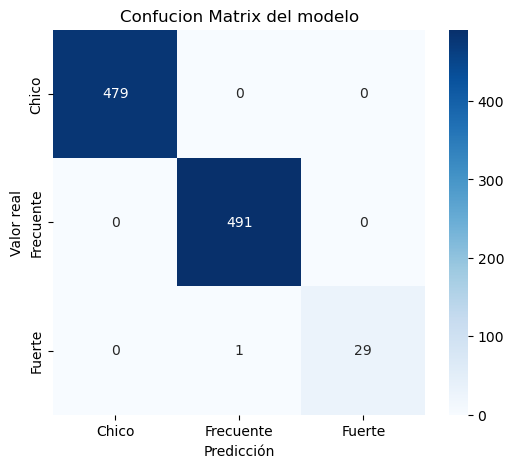

In [416]:
## 8. Visualizar como gráfico la confusion matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
xticklabels=['Chico','Frecuente','Fuerte'],
yticklabels=['Chico','Frecuente','Fuerte']
)
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Confucion Matrix del modelo")
plt.show()

## Evaluación del modelo

El modelo de clasificación basado en Decision Tree alcanzó un **accuracy de 0.999** en el conjunto de prueba.

Este resultado indica que el modelo logra predecir correctamente el tipo de cliente en prácticamente todos los casos evaluados.

Sin embargo, este nivel de precisión se explica en gran medida porque las variables utilizadas para entrenar el modelo son las mismas que se emplearon previamente para construir la segmentación mediante clustering.

Por lo tanto, el modelo no descubre una estructura completamente nueva, sino que **reproduce y valida la lógica de segmentación previamente identificada** en el análisis exploratorio.

Este resultado confirma que las variables de comportamiento de compra utilizadas en el proyecto explican de forma consistente la diferenciación entre los distintos tipos de clientes.

## Visualización del árbol de decisión

Con el objetivo de interpretar el funcionamiento interno del modelo de clasificación, se procede a visualizar el **árbol de decisión generado durante el entrenamiento**.

Este tipo de representación permite observar las reglas utilizadas por el modelo para clasificar a los clientes en los distintos segmentos definidos previamente.

Cada nodo del árbol representa una condición basada en una de las variables predictoras, mientras que las ramas indican las posibles decisiones tomadas por el modelo a partir de dichos valores.

De esta manera, el árbol permite comprender de forma transparente cómo variables como **Total**, **Order Quantity**, **Discount %**, **Real Margin Total** y **Purchase Frequency** influyen en la clasificación final del tipo de cliente.

In [417]:
model_simple = DecisionTreeClassifier(max_depth=4, random_state=42)
model_simple.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


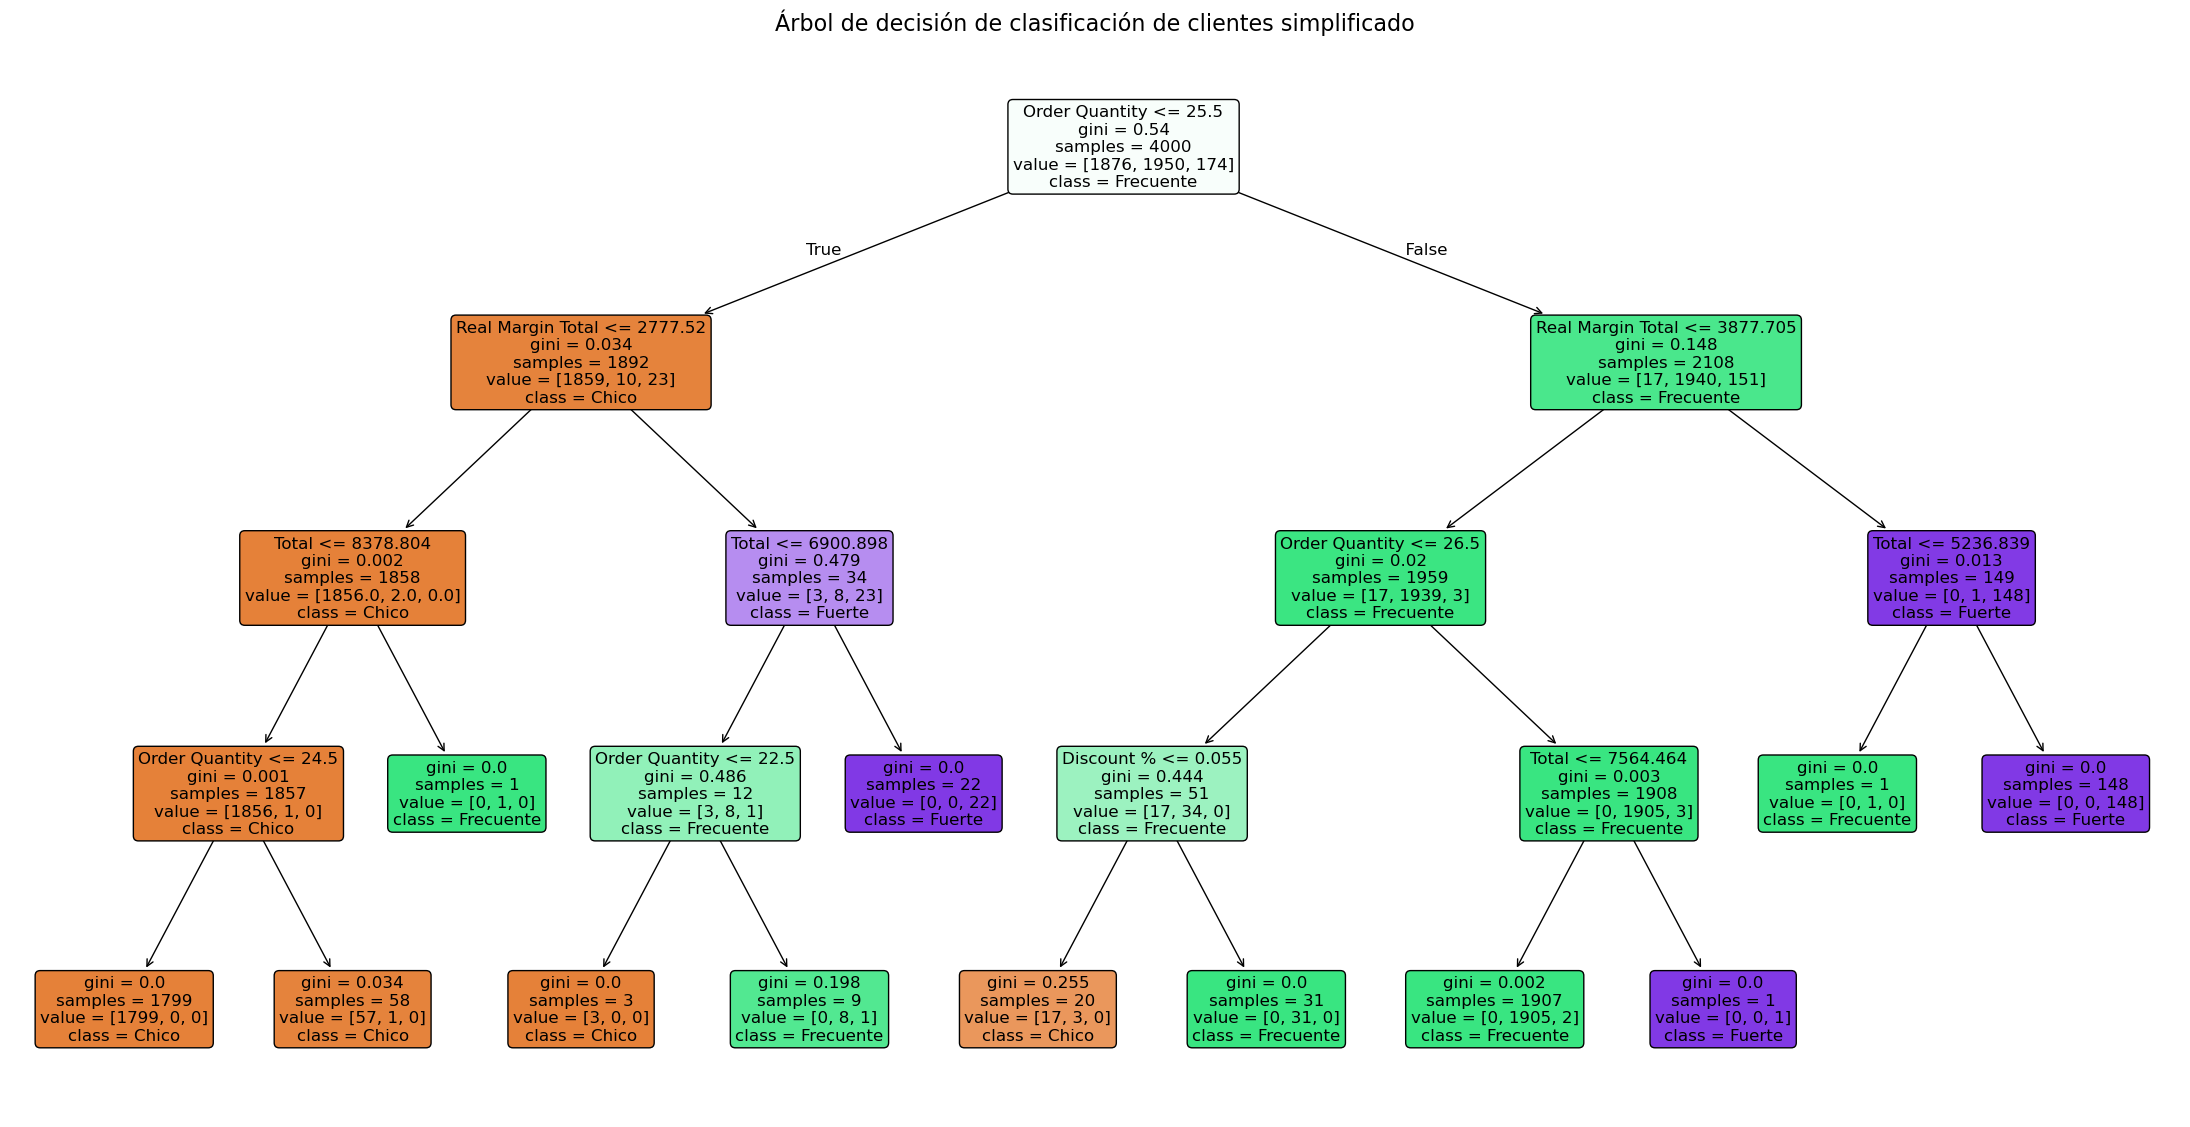

In [418]:
plt.figure(figsize=(28,14))
plot_tree(model_simple, 
         feature_names=features.columns,
         class_names=['Chico','Frecuente','Fuerte'],
         filled=True,
         rounded=True,
          fontsize=12
        )

plt.title("Árbol de decisión de clasificación de clientes simplificado", fontsize=16)
plt.show()

### Lectura del árbol de decisión

La visualización del árbol permite observar de manera transparente las reglas que el modelo utiliza para clasificar a los clientes.

Cada nodo muestra:

- la **variable de decisión** utilizada para dividir los datos
- el valor umbral aplicado
- la cantidad de registros analizados en ese punto
- la distribución de clases dentro del nodo
- y la clase dominante resultante

En este caso, variables como **Order Quantity**, **Real Margin Total** y **Total** aparecen como criterios principales de separación, lo que sugiere que estas dimensiones explican gran parte de la segmentación de clientes obtenida previamente mediante clustering.

La intensidad del color representa el grado de predominio de la clase dominante dentro de cada nodo: cuanto más intenso es el color, más homogéneo es el grupo resultante.

### Interpretación del árbol de decisión

El árbol de decisión representa el conjunto de reglas que el modelo utiliza para clasificar a los clientes en los distintos segmentos.

Cada nodo del árbol contiene la siguiente información:

- **Variable de decisión**: condición utilizada para dividir los datos (por ejemplo, *Order Quantity ≤ 25.5*).
- **gini**: medida de impureza del nodo. Valores cercanos a 0 indican grupos más homogéneos.
- **samples**: cantidad de registros que llegan a ese nodo.
- **value**: distribución de clases dentro del nodo en el formato `[Chico, Frecuente, Fuerte]`.
- **class**: clase dominante utilizada por el modelo para clasificar los registros en ese nodo.

Las tarjetas que no muestran una variable corresponden a **nodos hoja**, es decir, puntos donde el modelo ya ha llegado a una clasificación final y no necesita realizar más divisiones.

Cada ruta desde la raíz del árbol hasta una hoja representa una **regla de decisión completa** que el modelo utiliza para determinar el tipo de cliente a partir de sus características de compra.

### Reglas principales identificadas por el modelo

El árbol de decisión permite identificar algunas reglas simples que explican gran parte de la segmentación de clientes:

- Clientes con **baja cantidad de productos por compra** tienden a pertenecer al grupo de **clientes chicos**.
- Cuando la **cantidad de productos aumenta** y el **margen generado es mayor**, los clientes pasan a clasificarse como **clientes frecuentes**.
- Los **clientes fuertes** se caracterizan por combinar **altos valores de compra total y alto margen generado**, lo que los convierte en el segmento de mayor impacto económico para la empresa.

Estas reglas coinciden con los patrones observados previamente durante el análisis exploratorio y la segmentación mediante clustering.

## Conclusiones del análisis

El análisis realizado permitió identificar patrones claros en el comportamiento de compra de los clientes presentes en el dataset.

La auditoría inicial reveló inconsistencias en algunas variables económicas derivadas, lo que motivó una reconstrucción determinista de métricas clave como el margen real generado por cada venta.

Posteriormente, la segmentación de clientes mediante técnicas de clustering permitió identificar tres tipos principales de clientes: **clientes chicos, clientes frecuentes y clientes fuertes**, diferenciados principalmente por su volumen de compra y el margen económico que generan.

El análisis conjunto de clusters de clientes y productos evidenció que el negocio se sostiene gracias a la interacción entre distintos tipos de productos: algunos de **alta rotación**, otros de **alto impacto económico**, y un conjunto de productos de **bajo impacto individual pero relevantes para la diversidad del catálogo**.

Finalmente, el entrenamiento de un modelo supervisado de clasificación permitió validar que las variables de comportamiento de compra utilizadas en el análisis explican de forma consistente la segmentación de clientes observada.

En conjunto, el proyecto demuestra cómo la combinación de **auditoría de datos, análisis exploratorio, segmentación y modelos predictivos** puede contribuir a comprender mejor la estructura económica de un negocio basado en datos transaccionales.

## Metodología de trabajo y uso de herramientas de IA

El desarrollo del proyecto siguió una metodología iterativa de análisis de datos que incluyó las siguientes etapas:

1. **Exploración inicial del dataset (EDA)** para comprender la estructura de los datos.
2. **Auditoría de consistencia de variables**, detectando inconsistencias en columnas derivadas de cálculos financieros.
3. **Reconstrucción determinista de métricas económicas**, generando variables corregidas como `Real Margin Total`.
4. **Limpieza y refinamiento del dataframe**, eliminando columnas inconsistentes y manteniendo únicamente las variables relevantes para el análisis.
5. **Segmentación de clientes mediante clustering**, identificando distintos tipos de comportamiento de compra.
6. **Segmentación de productos**, analizando su impacto económico y su frecuencia de compra.
7. **Cruce entre clusters de clientes y productos**, permitiendo entender la relación entre tipos de clientes y tipos de productos.
8. **Visualización de resultados**, utilizando gráficos comparativos y mapas de calor para facilitar la interpretación.
9. **Entrenamiento de un modelo supervisado de clasificación**, con el objetivo de validar la segmentación obtenida y analizar las variables que explican la diferenciación entre clientes.

Esta metodología permitió combinar técnicas de **análisis exploratorio, segmentación no supervisada y modelos supervisados**, generando una comprensión integral del comportamiento comercial presente en el dataset.

### Integración de inteligencia artificial

Durante el desarrollo del proyecto se utilizaron herramientas de asistencia basadas en inteligencia artificial para apoyar el proceso de análisis y desarrollo del código.

Estas herramientas fueron empleadas principalmente para:

- validar sintaxis y estructura de código en Python
- discutir enfoques analíticos posibles
- mejorar la claridad en la documentación del notebook
- revisar interpretaciones del modelo y de las visualizaciones

No obstante, todas las decisiones analíticas, selección de variables, interpretación de resultados y construcción del flujo de trabajo fueron realizadas de manera consciente y supervisada por el autor del proyecto.

## Alcance y limitaciones del análisis

El análisis se basa en un dataset estático y en un conjunto limitado de variables transaccionales. En un contexto empresarial real, sería interesante incorporar información adicional como historial temporal de compras, características demográficas de los clientes o información sobre campañas comerciales.

Asimismo, futuras etapas del análisis podrían incluir modelos de predicción de demanda, análisis de retención de clientes o técnicas de forecasting para anticipar tendencias de ventas.